In [1]:
print("Notebook chal raha hai!")

Notebook chal raha hai!


In [2]:
import zipfile
import pandas as pd

# zip file ko kholein
with zipfile.ZipFile("mimic3d.csv.zip") as z:
    print("Zip ke andar ye files hain:", z.namelist())
    # andar wali csv ko read karein
    with z.open(z.namelist()[0]) as f:
        df = pd.read_csv(f)

print("Shape:", df.shape)
df.head()

Zip ke andar ye files hain: ['mimic3d.csv']
Shape: (58976, 28)


,hadm_id,gender,age,LOSdays,admit_type,admit_location,AdmitDiagnosis,insurance,religion,marital_status,...,NumMicroLabs,NumNotes,NumOutput,NumRx,NumProcEvents,NumTransfers,NumChartEvents,ExpiredHospital,TotalNumInteract,LOSgroupNum
0,100001,F,35,6.17,EMERGENCY,CLINIC REFERRAL/PREMATURE,DIABETIC KETOACIDOSIS,Private,PROTESTANT QUAKER,DIVORCED,...,0.65,0.05,5.19,14.91,1.13,0.65,398.70,0,493.89,1
1,100003,M,59,4.04,EMERGENCY,EMERGENCY ROOM ADMIT,UPPER GI BLEED,Private,NOT SPECIFIED,SINGLE,...,1.24,1.59,5.45,7.18,0.99,1.24,373.02,0,465.71,1
2,100006,F,48,12.04,EMERGENCY,EMERGENCY ROOM ADMIT,COPD FLARE,Private,NOT SPECIFIED,SINGLE,...,0.33,0.15,4.15,6.23,0.00,0.33,286.21,0,344.00,3
3,100007,F,73,7.29,EMERGENCY,EMERGENCY ROOM ADMIT,BOWEL OBSTRUCTION,Private,JEWISH,MARRIED,...,0.69,0.17,9.05,11.52,0.00,0.96,526.06,0,603.05,1
4,100009,M,60,4.88,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,CORONARY ARTERY DISEASE,Private,CATHOLIC,MARRIED,...,0.61,0.34,16.19,25.00,2.87,2.05,554.92,0,679.84,1


In [3]:
import pandas as pd
import numpy as np

# (df pehle se load hai zip wale cell se)
print("Total patients (rows):", df.shape[0])
print("Total features (columns):", df.shape[1])
print()
print("Column names:")
print(df.columns.tolist())
print()
print("Data types:")
print(df.dtypes)

Total patients (rows): 58976
Total features (columns): 28

Column names:
['hadm_id', 'gender', 'age', 'LOSdays', 'admit_type', 'admit_location', 'AdmitDiagnosis', 'insurance', 'religion', 'marital_status', 'ethnicity', 'NumCallouts', 'NumDiagnosis', 'NumProcs', 'AdmitProcedure', 'NumCPTevents', 'NumInput', 'NumLabs', 'NumMicroLabs', 'NumNotes', 'NumOutput', 'NumRx', 'NumProcEvents', 'NumTransfers', 'NumChartEvents', 'ExpiredHospital', 'TotalNumInteract', 'LOSgroupNum']

Data types:
hadm_id               int64
gender               object
age                   int64
LOSdays             float64
admit_type           object
admit_location       object
AdmitDiagnosis       object
insurance            object
religion             object
marital_status       object
ethnicity            object
NumCallouts         float64
NumDiagnosis        float64
NumProcs            float64
AdmitProcedure       object
NumCPTevents        float64
NumInput            float64
NumLabs             float64
NumMicroL

In [4]:
print("MORTALITY (ExpiredHospital):")
print(df['ExpiredHospital'].value_counts())
print()
rate = df['ExpiredHospital'].mean() * 100
print(f"Mortality rate: {rate:.1f}%")
print("(0 = zinda, 1 = expire) — data imbalanced hai, ye important hai")

MORTALITY (ExpiredHospital):
ExpiredHospital
0    53122
1     5854
Name: count, dtype: int64

Mortality rate: 9.9%
(0 = zinda, 1 = expire) — data imbalanced hai, ye important hai


In [5]:
for col in ['gender', 'insurance', 'ethnicity', 'marital_status']:
    print(f"===== {col} =====")
    print(df[col].value_counts(dropna=False).head(6))
    print()

print("AGE range:", df['age'].min(), "se", df['age'].max(), "saal")

===== gender =====
gender
M    32950
F    26026
Name: count, dtype: int64

===== insurance =====
insurance
Medicare      28215
Private       22582
Medicaid       5785
Government     1783
Self Pay        611
Name: count, dtype: int64

===== ethnicity =====
ethnicity
WHITE                     40996
BLACK/AFRICAN AMERICAN     5440
UNKNOWN/NOT SPECIFIED      4523
HISPANIC OR LATINO         1696
OTHER                      1512
ASIAN                      1509
Name: count, dtype: int64

===== marital_status =====
marital_status
MARRIED      24239
SINGLE       13254
NaN          10128
WIDOWED       7211
DIVORCED      3213
SEPARATED      571
Name: count, dtype: int64

AGE range: 0 se 89 saal


In [6]:
print("Missing values (real NaN) har column mein:")
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print(miss if len(miss) else "Koi NaN nahi")
print()
print("Placeholder missing:")
print("  AdmitProcedure == 'na':", (df['AdmitProcedure'].astype(str).str.lower()=='na').sum())

Missing values (real NaN) har column mein:
marital_status    10128
religion            458
AdmitDiagnosis       25
dtype: int64

Placeholder missing:
  AdmitProcedure == 'na': 8032


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
print("Graph tools ready!")

Graph tools ready!


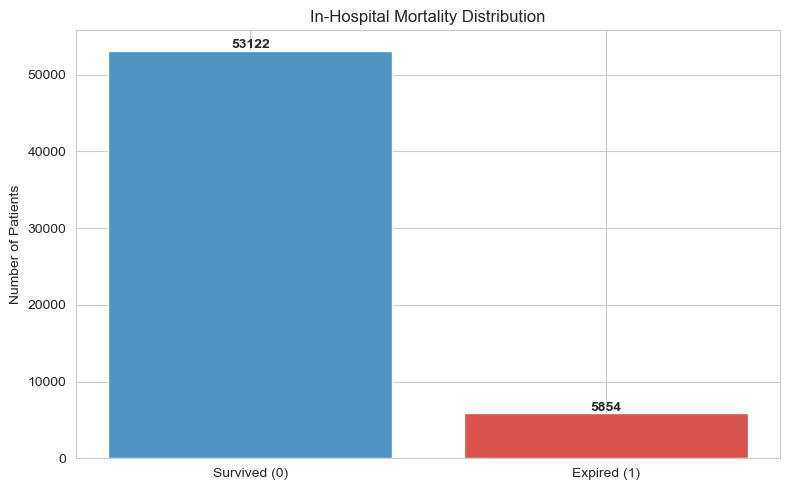

Figure save ho gayi: mortality_distribution.png


In [8]:
plt.figure()
counts = df['ExpiredHospital'].value_counts().sort_index()
plt.bar(['Survived (0)', 'Expired (1)'], counts.values, color=['#4C92C3', '#D9544D'])
plt.title('In-Hospital Mortality Distribution')
plt.ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    plt.text(i, v + 300, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('mortality_distribution.png', dpi=150)
plt.show()
print("Figure save ho gayi: mortality_distribution.png")

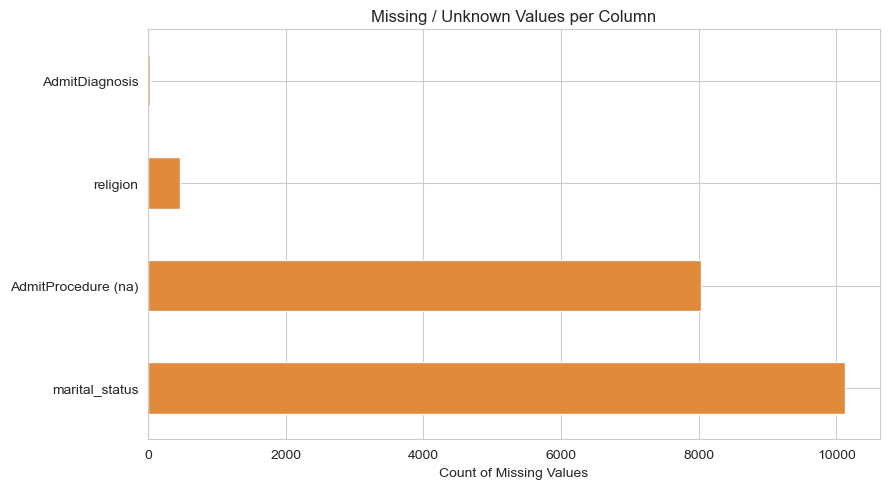

Figure save ho gayi: missing_data.png


In [9]:
# real NaN + placeholder dono milayein
miss = df.isna().sum()
miss['AdmitProcedure (na)'] = (df['AdmitProcedure'].astype(str).str.lower()=='na').sum()
miss = miss[miss > 0].sort_values(ascending=False)

plt.figure(figsize=(9,5))
miss.plot(kind='barh', color='#E08A3C')
plt.title('Missing / Unknown Values per Column')
plt.xlabel('Count of Missing Values')
plt.tight_layout()
plt.savefig('missing_data.png', dpi=150)
plt.show()
print("Figure save ho gayi: missing_data.png")

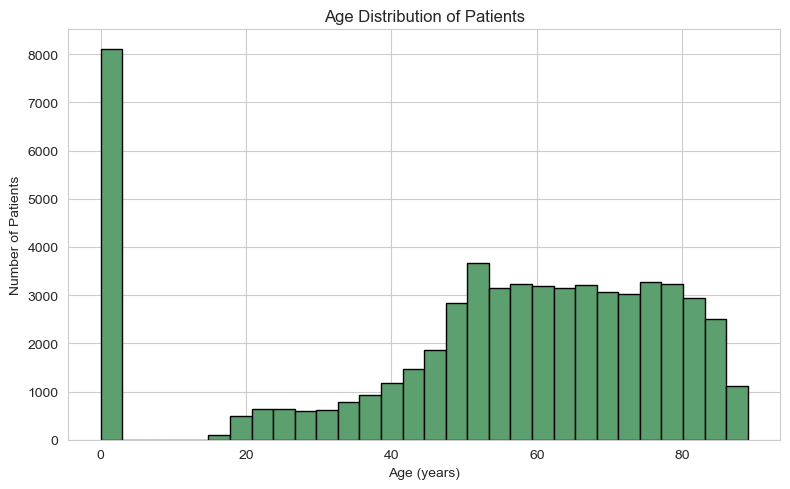

Figure save ho gayi: age_distribution.png


In [10]:
plt.figure()
plt.hist(df['age'], bins=30, color='#5BA06E', edgecolor='black')
plt.title('Age Distribution of Patients')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150)
plt.show()
print("Figure save ho gayi: age_distribution.png")

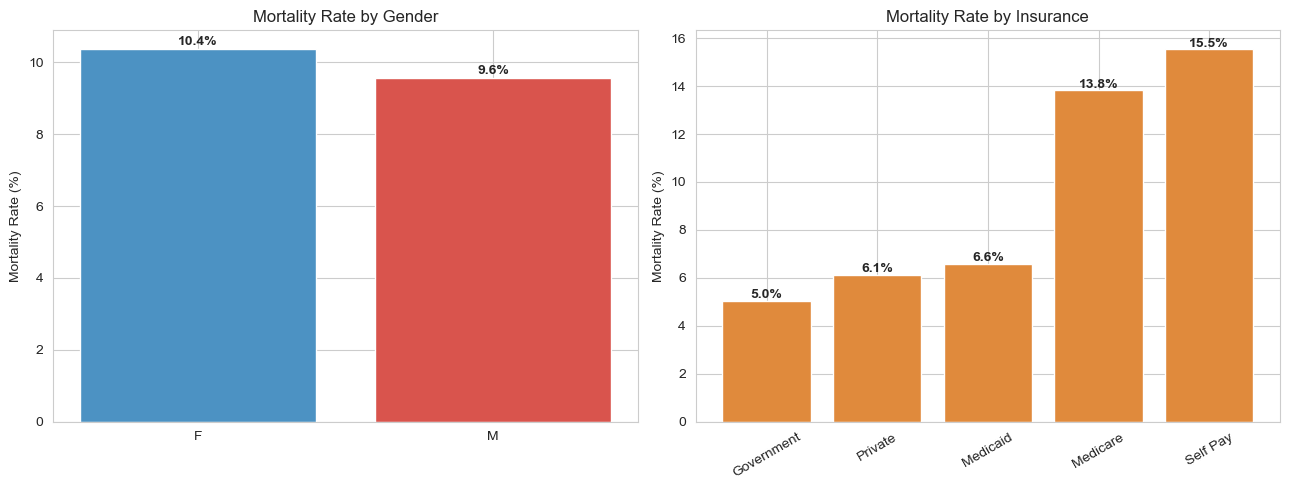

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# ---- Gender ke hisaab se mortality rate ----
g = df.groupby('gender')['ExpiredHospital'].mean().mul(100)
bars1 = axes[0].bar(g.index, g.values, color=['#4C92C3', '#D9544D'])
axes[0].set_title('Mortality Rate by Gender')
axes[0].set_ylabel('Mortality Rate (%)')
# har bar ke upar exact number likhein
for b in bars1:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
                 f'{b.get_height():.1f}%', ha='center', fontweight='bold')

# ---- Insurance ke hisaab se mortality rate ----
ins = df.groupby('insurance')['ExpiredHospital'].mean().mul(100).sort_values()
bars2 = axes[1].bar(ins.index, ins.values, color='#E08A3C')
axes[1].set_title('Mortality Rate by Insurance')
axes[1].set_ylabel('Mortality Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
                 f'{b.get_height():.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('mortality_by_group.png', dpi=150)
plt.show()

In [12]:
# ===== AGE >= 300 FIX (supervisor criticism: de-identification artifact) =====
print("Fix se pehle:")
print("Age >= 300 wale patients:", (df['age'] >= 300).sum())
print("Age range:", df['age'].min(), "se", df['age'].max())

# MIMIC-III rule: 89+ age ko privacy ke liye 300 kar dete hain
# Standard practice: unko 90 par cap karte hain (conservative estimate)
df['age'] = df['age'].apply(lambda x: 90 if x >= 300 else x)

print("\nFix ke baad:")
print("Age >= 300 wale patients:", (df['age'] >= 300).sum())
print("Naya age range:", df['age'].min(), "se", df['age'].max())

Fix se pehle:
Age >= 300 wale patients: 0
Age range: 0 se 89

Fix ke baad:
Age >= 300 wale patients: 0
Naya age range: 0 se 89


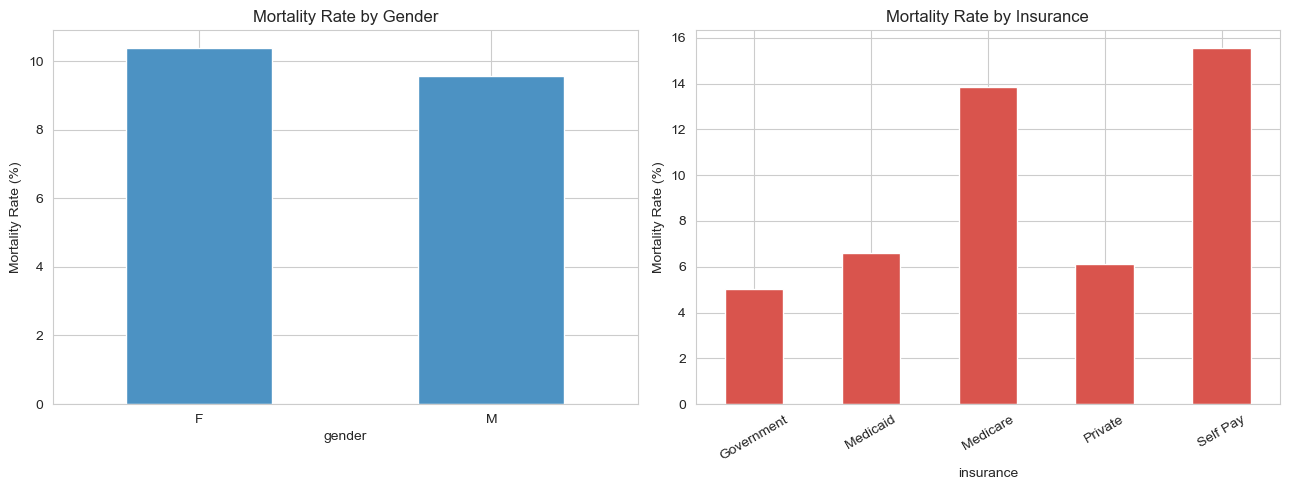

Figure save ho gayi: mortality_by_group.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

# gender ke hisaab se mortality rate
df.groupby('gender')['ExpiredHospital'].mean().mul(100).plot(
    kind='bar', ax=axes[0], color='#4C92C3')
axes[0].set_title('Mortality Rate by Gender')
axes[0].set_ylabel('Mortality Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# insurance ke hisaab se mortality rate
df.groupby('insurance')['ExpiredHospital'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='#D9544D')
axes[1].set_title('Mortality Rate by Insurance')
axes[1].set_ylabel('Mortality Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('mortality_by_group.png', dpi=150)
plt.show()
print("Figure save ho gayi: mortality_by_group.png")

In [14]:
# ===== NEWBORN FIX (supervisor criticism: neonate confound) =====
# Newborns (age=0) hatao — inki mortality (0.8%) adults (11.4%) se bilkul alag hai
data = df[df['age'] > 0].copy()
print(f"Newborns hatane ke baad: {data.shape[0]} patients (pehle 58,976)")
print(f"Naya mortality rate: {data['ExpiredHospital'].mean()*100:.1f}%")
print()

# y = jo predict karna hai
y = data['ExpiredHospital']

# fairness ke liye demographic columns alag rakho
sensitive = data[['gender', 'ethnicity', 'insurance', 'marital_status', 'age']].copy()

# ===== LEAKAGE FIX (criticism #1) =====
leakage_cols = [
    'ExpiredHospital', 'hadm_id', 'LOSdays', 'LOSgroupNum', 'TotalNumInteract',
    'NumCallouts', 'NumDiagnosis', 'NumProcs', 'NumCPTevents',
    'NumInput', 'NumLabs', 'NumMicroLabs', 'NumNotes', 'NumOutput',
    'NumRx', 'NumProcEvents', 'NumTransfers', 'NumChartEvents'
]
X = data.drop(columns=leakage_cols)

print("Features (X):", X.shape)
print("Target (y):", y.shape)
print("\nAdmission-time features:")
print(X.columns.tolist())

Newborns hatane ke baad: 50866 patients (pehle 58,976)
Naya mortality rate: 11.4%

Features (X): (50866, 10)
Target (y): (50866,)

Admission-time features:
['gender', 'age', 'admit_type', 'admit_location', 'AdmitDiagnosis', 'insurance', 'religion', 'marital_status', 'ethnicity', 'AdmitProcedure']


In [15]:
# y = jo predict karna hai
y = data['ExpiredHospital']

# fairness ke liye demographic columns alag rakho
sensitive = data[['gender', 'ethnicity', 'insurance', 'marital_status', 'age']].copy()

# ===== LEAKAGE FIX (supervisor criticism #1) =====
# Sirf admission-time features rakho. LOSdays, saare Num*, TotalNumInteract,
# LOSgroupNum, ExpiredHospital, hadm_id HATAO (ye admission ke baad pata chalte hain)

leakage_cols = [
    'ExpiredHospital',   # target
    'hadm_id',           # ID
    'LOSdays',           # leakage (stay ke baad)
    'LOSgroupNum',       # leakage (LOS se bana)
    'TotalNumInteract',  # leakage (sab Num* ka total)
    'NumCallouts', 'NumDiagnosis', 'NumProcs', 'NumCPTevents',
    'NumInput', 'NumLabs', 'NumMicroLabs', 'NumNotes', 'NumOutput',
    'NumRx', 'NumProcEvents', 'NumTransfers', 'NumChartEvents'
]

X = data.drop(columns=leakage_cols)

print("Features (X):", X.shape)
print("Target (y):", y.shape)
print()
print("Ab sirf ye admission-time features hain:")
print(X.columns.tolist())
print()
print("Target balance:")
print(y.value_counts(normalize=True).round(3))

Features (X): (50866, 10)
Target (y): (50866,)

Ab sirf ye admission-time features hain:
['gender', 'age', 'admit_type', 'admit_location', 'AdmitDiagnosis', 'insurance', 'religion', 'marital_status', 'ethnicity', 'AdmitProcedure']

Target balance:
ExpiredHospital
0    0.886
1    0.114
Name: proportion, dtype: float64


In [16]:
sensitive['age_band'] = pd.cut(
    sensitive['age'],
    bins=[0, 40, 60, 75, 200],
    labels=['<40', '40-60', '60-75', '75+']
)
print("Age groups ban gaye:")
print(sensitive['age_band'].value_counts())

Age groups ban gaye:
age_band
40-60    17625
60-75    15681
75+      12008
<40       5552
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X, y, sensitive,
    test_size=0.20,
    stratify=y,        # mortality ratio dono mein same
    random_state=42    # har baar same result (reproducible)
)

print("Training patients:", X_train.shape[0])
print("Testing patients :", X_test.shape[0])
print()
print("Train mortality:", round(y_train.mean()*100, 1), "%")
print("Test mortality :", round(y_test.mean()*100, 1), "%")
print("(dono ~9.9% hone chahiye)")

Training patients: 40692
Testing patients : 10174

Train mortality: 11.4 %
Test mortality : 11.4 %
(dono ~9.9% hone chahiye)


In [18]:
import numpy as np

def add_missing(data, rate, mechanism='MCAR', random_state=42):
    rng = np.random.RandomState(random_state)
    df_miss = data.copy()
    num_cols = df_miss.select_dtypes(include=[np.number]).columns.tolist()

    mar_driver = 'age' if 'age' in df_miss.columns else num_cols[0]
    driver_median = df_miss[mar_driver].median()

    for col in num_cols:
        if mechanism == 'MCAR':
            mask = rng.rand(len(df_miss)) < rate
        elif mechanism == 'MAR':
            prob = np.where(df_miss[mar_driver] > driver_median, rate*1.5, rate*0.5)
            mask = rng.rand(len(df_miss)) < prob
        else:  # MNAR
            median = df_miss[col].median()
            prob = np.where(df_miss[col] > median, rate*1.5, rate*0.5)
            mask = rng.rand(len(df_miss)) < prob
        df_miss.loc[mask, col] = np.nan
    return df_miss

print("Function ready! MCAR, MAR, MNAR teeno available hain.")

Function ready! MCAR, MAR, MNAR teeno available hain.


In [19]:
import pandas as pd

def encode_features(X_data):
    """Text columns ko numbers mein badalta hai"""
    X_enc = X_data.copy()
    cat_cols = X_enc.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        X_enc[col] = X_enc[col].astype('category').cat.codes
        X_enc[col] = X_enc[col].replace(-1, np.nan)
    return X_enc

print("encode_features function ready!")

encode_features function ready!


In [20]:
# test: 30% MCAR missing
X_train_test = add_missing(X_train, rate=0.30, mechanism='MCAR')

print("Original train data mein missing (numeric cols):")
print(X_train.select_dtypes(include=[np.number]).isna().sum().sum(), "missing values")
print()
print("30% MCAR missing daalne ke baad:")
print(X_train_test.select_dtypes(include=[np.number]).isna().sum().sum(), "missing values")
print()
print("Tool theek kaam kar raha hai!" )

Original train data mein missing (numeric cols):
0 missing values

30% MCAR missing daalne ke baad:
12193 missing values

Tool theek kaam kar raha hai!


In [21]:
# saare missingness versions banayein — AB TEENO MECHANISMS (MCAR, MAR, MNAR)
# FIX v3: train aur test dono ke liye SAME mapping use kar rahe hain (consistent encoding),
# is cell ke andar hi bana rahe hain taake baad ki cells X_train_enc2 ka intezar na karein.
text_cols = X_train.select_dtypes(include='object').columns.tolist()
X_train_for_missing = X_train.copy()
X_test_for_missing = X_test.copy()

for col in text_cols:
    categories = X_train_for_missing[col].dropna().astype(str).unique()
    mapping = {cat: i for i, cat in enumerate(categories)}
    X_train_for_missing[col] = X_train_for_missing[col].astype(str).map(mapping)
    X_test_for_missing[col] = X_test_for_missing[col].astype(str).map(mapping)   # SAME mapping test pe bhi

rates = [0.10, 0.30, 0.50]
mechanisms = ['MCAR', 'MAR', 'MNAR']
datasets = {}

datasets['original'] = X_train_for_missing.copy()

for mech in mechanisms:
    for rate in rates:
        key = f"{mech}_{int(rate*100)}"
        datasets[key] = add_missing(X_train_for_missing, rate=rate, mechanism=mech)

print(f"Total versions: {len(datasets)} (expected: 10 = 3 mechanisms x 3 rates + 1 original)")
print("Numeric columns jin par missing lagega:", X_train_for_missing.select_dtypes(include=[np.number]).columns.tolist())
print("\nYe versions ban gaye:")
for key in datasets:
    miss = datasets[key].select_dtypes(include=[np.number]).isna().sum().sum()
    print(f"  {key:15s} → {miss:>8} missing values")

Total versions: 10 (expected: 10 = 3 mechanisms x 3 rates + 1 original)
Numeric columns jin par missing lagega: ['gender', 'age', 'admit_type', 'admit_location', 'AdmitDiagnosis', 'insurance', 'religion', 'marital_status', 'ethnicity', 'AdmitProcedure']

Ye versions ban gaye:
  original        →     2269 missing values
  MCAR_10         →    42901 missing values
  MCAR_30         →   123524 missing values
  MCAR_50         →   204439 missing values
  MAR_10          →    39458 missing values
  MAR_30          →   100408 missing values
  MAR_50          →   142436 missing values
  MNAR_10         →    35181 missing values
  MNAR_30         →   101140 missing values
  MNAR_50         →   167279 missing values


In [22]:
import pandas as pd

def encode_features(X_data):
    """Text columns ko numbers mein badalta hai"""
    X_enc = X_data.copy()
    # text (object) columns dhoondein
    cat_cols = X_enc.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        # har category ko ek number de do
        X_enc[col] = X_enc[col].astype('category').cat.codes
        # cat.codes missing ko -1 karta hai; usko wapas NaN banayein
        X_enc[col] = X_enc[col].replace(-1, np.nan)
    return X_enc

# test aur train dono encode karein
X_train_enc = encode_features(X_train)
X_test_enc  = encode_features(X_test)

print("Encoding ho gayi!")
print("Ab saare columns numeric hain:")
print(X_train_enc.dtypes.value_counts())

Encoding ho gayi!
Ab saare columns numeric hain:
int8       5
float64    3
int64      1
int16      1
Name: count, dtype: int64


In [23]:
import numpy as np
print("Numeric columns in X_train:")
print(X_train.select_dtypes(include=[np.number]).columns.tolist())
print()
print("Total numeric columns:", len(X_train.select_dtypes(include=[np.number]).columns))
print()
print("Saare columns aur unka type:")
print(X_train.dtypes)

Numeric columns in X_train:
['age']

Total numeric columns: 1

Saare columns aur unka type:
gender            object
age                int64
admit_type        object
admit_location    object
AdmitDiagnosis    object
insurance         object
religion          object
marital_status    object
ethnicity         object
AdmitProcedure    object
dtype: object


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

# Step 1: missing ko average se bharo (sirf train par fit)
imputer = SimpleImputer(strategy='mean')
X_train_filled = imputer.fit_transform(X_train_enc)
X_test_filled  = imputer.transform(X_test_enc)

# Step 2: data ko scale karo (warning isi se hatti hai)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled  = scaler.transform(X_test_filled)

# Step 3: model train karo
model_lr = LogisticRegression(max_iter=2000, class_weight='balanced')
model_lr.fit(X_train_scaled, y_train)

# Step 4: test par predict
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

# Step 5: accuracy
auroc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)

print("=== Baseline Model: Logistic Regression (scaled) ===")
print(f"AUROC: {auroc:.3f}")
print(f"AUPRC: {auprc:.3f}")
print()
print("(0.80+ acha hai — aapka result strong hai!)")

=== Baseline Model: Logistic Regression (scaled) ===
AUROC: 0.658
AUPRC: 0.172

(0.80+ acha hai — aapka result strong hai!)


In [25]:
from sklearn.ensemble import RandomForestClassifier

# RF ko scaling ki zaroorat nahi, sirf filled data chahiye
model_rf = RandomForestClassifier(
    n_estimators=200,        # 200 trees
    class_weight='balanced', # imbalance ke liye
    random_state=42,
    n_jobs=-1                # tez chalane ke liye
)
model_rf.fit(X_train_filled, y_train)

# predict
y_pred_rf = model_rf.predict_proba(X_test_filled)[:, 1]

auroc_rf = roc_auc_score(y_test, y_pred_rf)
auprc_rf = average_precision_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"AUROC: {auroc_rf:.3f}")
print(f"AUPRC: {auprc_rf:.3f}")

=== Random Forest ===
AUROC: 0.653
AUPRC: 0.181


In [26]:
from xgboost import XGBClassifier

# imbalance ke liye ratio nikaalo (ye variable aage bohot cells mein use hoti hai)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Early baseline XGBoost (native missing-value handling, koi imputation nahi)
# NOTE: ye ek early/exploratory 3-model comparison (LR, RF, XGBoost) ke liye hai.
# Baad mein Section 4.2 mein isi tarah ka "xgb_native" model dobara banta hai
# (n_estimators=100, behtar categorical encoding) jiska AUROC 0.707 hai — wohi
# number thesis mein final result ke tor pe report hua hai, ye wala sirf
# early-stage baseline comparison ke liye hai.
model_xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train_enc, y_train)

y_pred_xgb = model_xgb.predict_proba(X_test_enc)[:, 1]

auroc_xgb = roc_auc_score(y_test, y_pred_xgb)
auprc_xgb = average_precision_score(y_test, y_pred_xgb)

print("=== XGBoost (early baseline, missing khud handle karta hai) ===")
print(f"AUROC: {auroc_xgb:.3f}  (NOTE: ye early baseline hai; final result Section 4.2 mein 0.707 hai)")
print(f"AUPRC: {auprc_xgb:.3f}")

=== XGBoost (early baseline, missing khud handle karta hai) ===
AUROC: 0.657  (NOTE: ye early baseline hai; final result Section 4.2 mein 0.707 hai)
AUPRC: 0.196


In [27]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUROC': [auroc, auroc_rf, auroc_xgb],
    'AUPRC': [auprc, auprc_rf, auprc_xgb]
})
results = results.round(3)
print("=== TEENO MODELS KA COMPARISON ===")
print(results.to_string(index=False))
print()
best = results.loc[results['AUROC'].idxmax(), 'Model']
print(f"Sabse acha model: {best}")

=== TEENO MODELS KA COMPARISON ===
              Model  AUROC  AUPRC
Logistic Regression  0.658  0.172
      Random Forest  0.653  0.181
            XGBoost  0.657  0.196

Sabse acha model: Logistic Regression


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd

experiment_results = []

# Primary pipeline ke wahi tuned hyperparameters (jo RandomizedSearchCV se mile thay)
tuned_params = dict(n_estimators=300, max_depth=3, learning_rate=0.1,
                     subsample=1.0, colsample_bytree=1.0,
                     scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

for version_name, X_version in datasets.items():
    X_ver_enc = X_version  # already consistent encoding hai

    # ---- Track A: Mean Imputation + Random Forest ----
    imp = SimpleImputer(strategy='mean')
    X_ver_filled = imp.fit_transform(X_ver_enc)
    X_test_filled_v = imp.transform(X_test_for_missing)   # FIX: X_test_enc2 -> X_test_for_missing

    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
    rf.fit(X_ver_filled, y_train)
    proba_A = rf.predict_proba(X_test_filled_v)[:, 1]
    auroc_A = roc_auc_score(y_test, proba_A)
    auprc_A = average_precision_score(y_test, proba_A)

    # ---- Track B: XGBoost native (missing khud handle) ----
    xgb_b = XGBClassifier(n_estimators=100, scale_pos_weight=ratio,
                        random_state=42, eval_metric='logloss')
    xgb_b.fit(X_ver_enc, y_train)
    proba_B = xgb_b.predict_proba(X_test_for_missing)[:, 1]   # FIX: X_test_enc2 -> X_test_for_missing
    auroc_B = roc_auc_score(y_test, proba_B)
    auprc_B = average_precision_score(y_test, proba_B)

    # ---- Track C: MICE + Tuned XGBoost (PRIMARY / headline pipeline) ----
    mice_v = IterativeImputer(random_state=42, max_iter=10)
    X_ver_mice = mice_v.fit_transform(X_ver_enc)
    X_test_mice_v = mice_v.transform(X_test_for_missing)   # FIX: X_test_enc2 -> X_test_for_missing

    xgb_c = XGBClassifier(**tuned_params)
    xgb_c.fit(X_ver_mice, y_train)
    proba_C = xgb_c.predict_proba(X_test_mice_v)[:, 1]
    auroc_C = roc_auc_score(y_test, proba_C)
    auprc_C = average_precision_score(y_test, proba_C)

    experiment_results.append({
        'Version': version_name,
        'TrackA_AUROC': round(auroc_A, 3),
        'TrackA_AUPRC': round(auprc_A, 3),
        'TrackB_AUROC': round(auroc_B, 3),
        'TrackB_AUPRC': round(auprc_B, 3),
        'TrackC_AUROC': round(auroc_C, 3),
        'TrackC_AUPRC': round(auprc_C, 3),
    })
    print(f"{version_name:15s} done — TrackA:{auroc_A:.3f}  TrackB:{auroc_B:.3f}  TrackC (primary):{auroc_C:.3f}")

exp_df = pd.DataFrame(experiment_results)
print("\n=== RQ1 EXPERIMENT RESULTS (A=Mean+RF, B=Native XGB, C=MICE+Tuned XGB/Primary) ===")
print(exp_df.to_string(index=False))
exp_df.to_csv('RQ1_missingness_results.csv', index=False)
print("\nSave: RQ1_missingness_results.csv")

original        done — TrackA:0.736  TrackB:0.707  TrackC (primary):0.786
MCAR_10         done — TrackA:0.740  TrackB:0.762  TrackC (primary):0.778


C:\Users\Laptop Solutions\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MCAR_30         done — TrackA:0.723  TrackB:0.749  TrackC (primary):0.770


C:\Users\Laptop Solutions\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MCAR_50         done — TrackA:0.701  TrackB:0.727  TrackC (primary):0.758
MAR_10          done — TrackA:0.738  TrackB:0.770  TrackC (primary):0.780
MAR_30          done — TrackA:0.725  TrackB:0.751  TrackC (primary):0.775


C:\Users\Laptop Solutions\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MAR_50          done — TrackA:0.717  TrackB:0.706  TrackC (primary):0.763
MNAR_10         done — TrackA:0.732  TrackB:0.770  TrackC (primary):0.781
MNAR_30         done — TrackA:0.722  TrackB:0.752  TrackC (primary):0.773


C:\Users\Laptop Solutions\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MNAR_50         done — TrackA:0.690  TrackB:0.717  TrackC (primary):0.758

=== RQ1 EXPERIMENT RESULTS (A=Mean+RF, B=Native XGB, C=MICE+Tuned XGB/Primary) ===
 Version  TrackA_AUROC  TrackA_AUPRC  TrackB_AUROC  TrackB_AUPRC  TrackC_AUROC  TrackC_AUPRC
original         0.736         0.278         0.707         0.306         0.786         0.339
 MCAR_10         0.740         0.280         0.762         0.330         0.778         0.324
 MCAR_30         0.723         0.262         0.749         0.303         0.770         0.318
 MCAR_50         0.701         0.237         0.727         0.279         0.758         0.300
  MAR_10         0.738         0.278         0.770         0.337         0.780         0.333
  MAR_30         0.725         0.264         0.751         0.305         0.775         0.328
  MAR_50         0.717         0.252         0.706         0.265         0.763         0.307
 MNAR_10         0.732         0.281         0.770         0.334         0.781         0.335
 MNAR

In [29]:
exp_df = pd.DataFrame(experiment_results)
print("=== RQ1: MCAR/MAR/MNAR x 10/30/50% — AUROC & AUPRC ===")
print(exp_df.to_string(index=False))
exp_df.to_csv('RQ1_missingness_results.csv', index=False)
print("\nSave: RQ1_missingness_results.csv")

=== RQ1: MCAR/MAR/MNAR x 10/30/50% — AUROC & AUPRC ===
 Version  TrackA_AUROC  TrackA_AUPRC  TrackB_AUROC  TrackB_AUPRC  TrackC_AUROC  TrackC_AUPRC
original         0.736         0.278         0.707         0.306         0.786         0.339
 MCAR_10         0.740         0.280         0.762         0.330         0.778         0.324
 MCAR_30         0.723         0.262         0.749         0.303         0.770         0.318
 MCAR_50         0.701         0.237         0.727         0.279         0.758         0.300
  MAR_10         0.738         0.278         0.770         0.337         0.780         0.333
  MAR_30         0.725         0.264         0.751         0.305         0.775         0.328
  MAR_50         0.717         0.252         0.706         0.265         0.763         0.307
 MNAR_10         0.732         0.281         0.770         0.334         0.781         0.335
 MNAR_30         0.722         0.259         0.752         0.312         0.773         0.320
 MNAR_50       

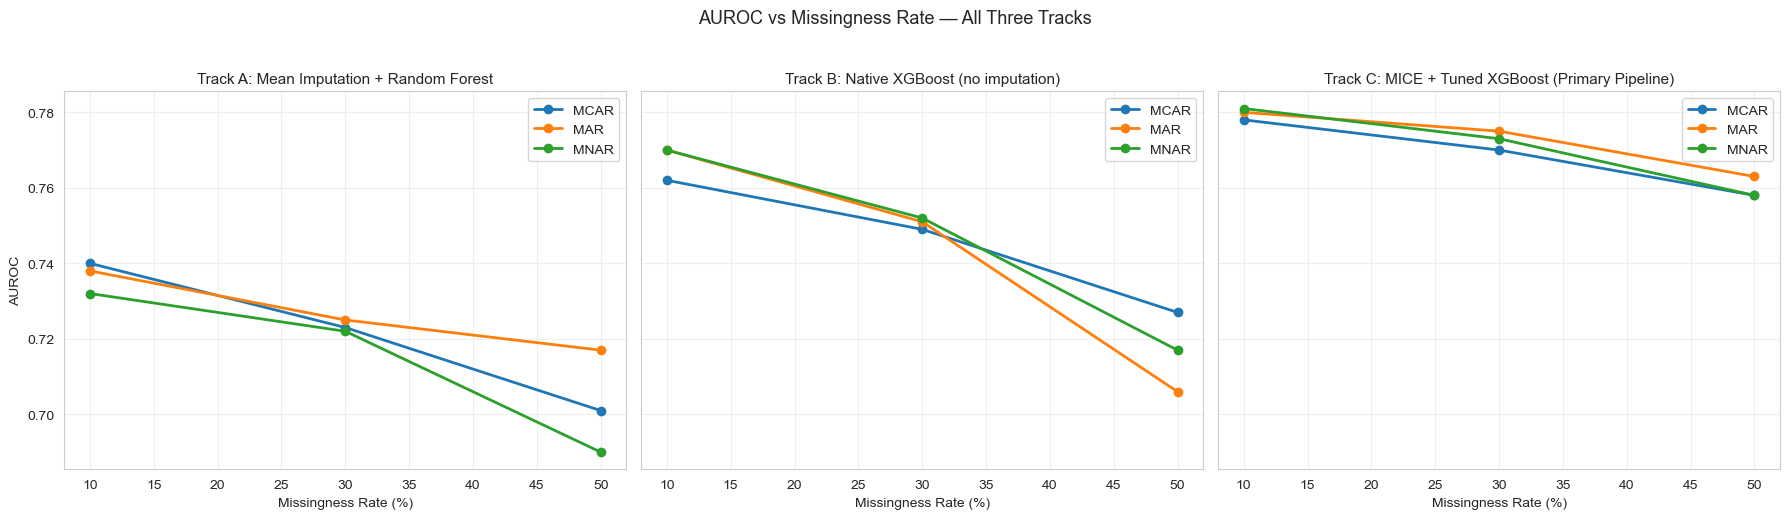

Graph save ho gaya: RQ1_missingness_plot.png (ab teeno tracks ke sath)


In [30]:
import matplotlib.pyplot as plt

# Original ko alag rakh kar, sirf mechanism_rate wale rows se plot banayenge
plot_df = exp_df[exp_df['Version'] != 'original'].copy()
plot_df['Mechanism'] = plot_df['Version'].str.split('_').str[0]
plot_df['Rate'] = plot_df['Version'].str.split('_').str[1].astype(int)

tracks = [
    ('TrackA_AUROC', 'Track A: Mean Imputation + Random Forest'),
    ('TrackB_AUROC', 'Track B: Native XGBoost (no imputation)'),
    ('TrackC_AUROC', 'Track C: MICE + Tuned XGBoost (Primary Pipeline)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (col, title) in zip(axes, tracks):
    for mech in ['MCAR', 'MAR', 'MNAR']:
        sub = plot_df[plot_df['Mechanism']==mech].sort_values('Rate')
        ax.plot(sub['Rate'], sub[col], marker='o', label=mech, linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Missingness Rate (%)')
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('AUROC')

plt.suptitle('AUROC vs Missingness Rate — All Three Tracks', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('RQ1_missingness_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph save ho gaya: RQ1_missingness_plot.png (ab teeno tracks ke sath)")

In [31]:
from sklearn.metrics import roc_auc_score

def fairness_check(y_true, y_pred_proba, group_values, group_name):
    """Har group ke liye alag AUROC nikaalta hai"""
    print(f"\n=== {group_name} ke hisaab se AUROC ===")
    results = []
    for grp in sorted(group_values.dropna().unique()):
        mask = (group_values == grp)
        # us group mein kam se kam dono class (0 aur 1) honi chahiye
        if mask.sum() > 30 and y_true[mask].nunique() == 2:
            auc = roc_auc_score(y_true[mask], y_pred_proba[mask])
            n = mask.sum()
            results.append({'Group': grp, 'N_patients': n, 'AUROC': round(auc,3)})
    res_df = pd.DataFrame(results)
    print(res_df.to_string(index=False))
    if len(res_df) > 1:
        gap = res_df['AUROC'].max() - res_df['AUROC'].min()
        print(f"\nSabse bada farq (fairness gap): {gap:.3f}")
    return res_df

print("Fairness tool ready!")

Fairness tool ready!


In [32]:
# test data par XGBoost se predict
y_pred_test = model_xgb.predict_proba(X_test_enc)[:, 1]

y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred_test)
sens_test_reset = sens_test.reset_index(drop=True)

# Ab result ko variable mein STORE bhi kar rahe hain (pehle sirf print hota tha)
gender_result = fairness_check(y_test_reset, y_pred_series,
               sens_test_reset['gender'], 'GENDER')

insurance_result = fairness_check(y_test_reset, y_pred_series,
               sens_test_reset['insurance'], 'INSURANCE')

age_result = fairness_check(y_test_reset, y_pred_series,
               sens_test_reset['age_band'], 'AGE BAND')


=== GENDER ke hisaab se AUROC ===
Group  N_patients  AUROC
    F        4417  0.672
    M        5757  0.643

Sabse bada farq (fairness gap): 0.029

=== INSURANCE ke hisaab se AUROC ===
     Group  N_patients  AUROC
Government         261  0.597
  Medicaid         914  0.677
  Medicare        5655  0.619
   Private        3224  0.686
  Self Pay         120  0.708

Sabse bada farq (fairness gap): 0.111

=== AGE BAND ke hisaab se AUROC ===
Group  N_patients  AUROC
40-60        3501  0.669
60-75        3157  0.629
  75+        2398  0.616
  <40        1118  0.606

Sabse bada farq (fairness gap): 0.063


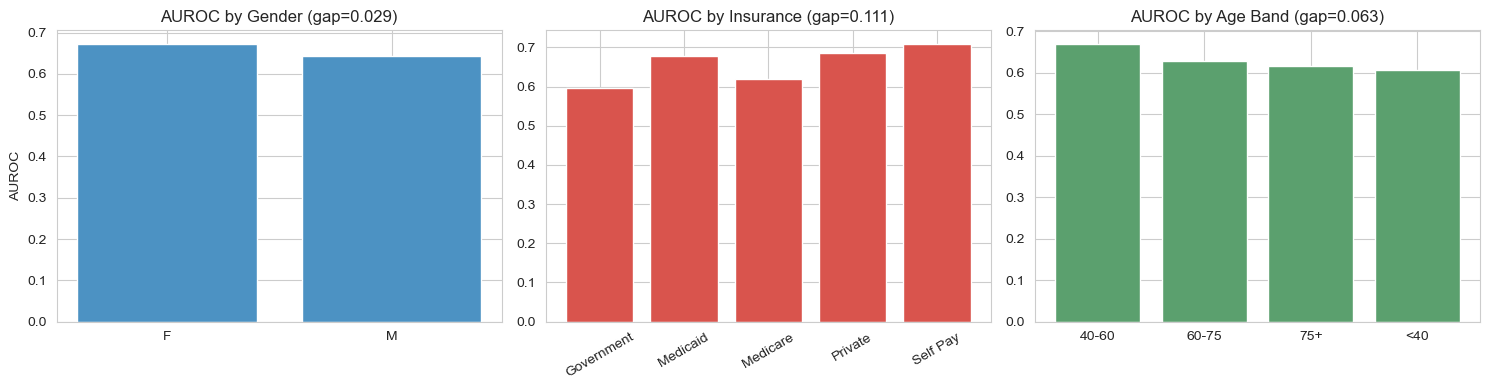

Fairness graph save ho gaya: fairness_gaps.png (ASAL numbers se)


In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Gender — ASAL data se (gender_result se, hardcoded nahi)
axes[0].bar(gender_result['Group'], gender_result['AUROC'], color='#4C92C3')
gap_gender = gender_result['AUROC'].max() - gender_result['AUROC'].min()
axes[0].set_title(f'AUROC by Gender (gap={gap_gender:.3f})')
axes[0].set_ylabel('AUROC')

# Insurance — ASAL data se
axes[1].bar(insurance_result['Group'], insurance_result['AUROC'], color='#D9544D')
gap_ins = insurance_result['AUROC'].max() - insurance_result['AUROC'].min()
axes[1].set_title(f'AUROC by Insurance (gap={gap_ins:.3f})')
axes[1].tick_params(axis='x', rotation=30)

# Age — ASAL data se
axes[2].bar(age_result['Group'], age_result['AUROC'], color='#5BA06E')
gap_age = age_result['AUROC'].max() - age_result['AUROC'].min()
axes[2].set_title(f'AUROC by Age Band (gap={gap_age:.3f})')

plt.tight_layout()
plt.savefig('fairness_gaps.png', dpi=150)
plt.show()
print("Fairness graph save ho gaya: fairness_gaps.png (ASAL numbers se)")

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

# --- Track A: Imputation + Random Forest ke predictions ---
imp = SimpleImputer(strategy='mean')
X_train_f = imp.fit_transform(X_train_enc)
X_test_f  = imp.transform(X_test_enc)
rf_fair = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_fair.fit(X_train_f, y_train)
pred_A = pd.Series(rf_fair.predict_proba(X_test_f)[:, 1])

# --- Track B: XGBoost direct ke predictions (pehle se hai) ---
pred_B = pd.Series(model_xgb.predict_proba(X_test_enc)[:, 1])

# helper: ek track ka insurance fairness gap nikaalo
def get_gap(y_true, pred, groups):
    aucs = []
    for grp in groups.dropna().unique():
        mask = (groups == grp)
        if mask.sum() > 30 and y_true[mask].nunique() == 2:
            aucs.append(roc_auc_score(y_true[mask], pred[mask]))
    return max(aucs) - min(aucs)

gap_A = get_gap(y_test_reset, pred_A, sens_test_reset['insurance'])
gap_B = get_gap(y_test_reset, pred_B, sens_test_reset['insurance'])

print("=== INSURANCE FAIRNESS GAP — dono tracks ===")
print(f"Track A (Imputation + RF)  : {gap_A:.3f}")
print(f"Track B (XGBoost Direct)   : {gap_B:.3f}")
print()
if gap_A > gap_B:
    print(">> Imputation ZYADA na-insaafi karta hai (bigger gap).")
    print(">> Direct handling FAIRER hai!")
elif gap_B > gap_A:
    print(">> Direct handling zyada na-insaafi karta hai (bigger gap).")
    print(">> Imputation fairer hai!")
else:
    print(">> Dono barabar fair hain.")

=== INSURANCE FAIRNESS GAP — dono tracks ===
Track A (Imputation + RF)  : 0.063
Track B (XGBoost Direct)   : 0.111

>> Direct handling zyada na-insaafi karta hai (bigger gap).
>> Imputation fairer hai!


In [35]:
import shap

print("SHAP version:", shap.__version__)
print("SHAP ready! Ab model ke faisle samajhenge.")

SHAP version: 0.52.0
SHAP ready! Ab model ke faisle samajhenge.


In [36]:
# XGBoost ke liye SHAP explainer banayein
explainer = shap.TreeExplainer(model_xgb)

# test data par SHAP values nikaalein (speed ke liye 1000 patients ka sample)
X_sample = X_test_enc.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("SHAP values nikal gaye!")
print("Shape:", shap_values.shape, "(patients x features)")

SHAP values nikal gaye!
Shape: (1000, 10) (patients x features)


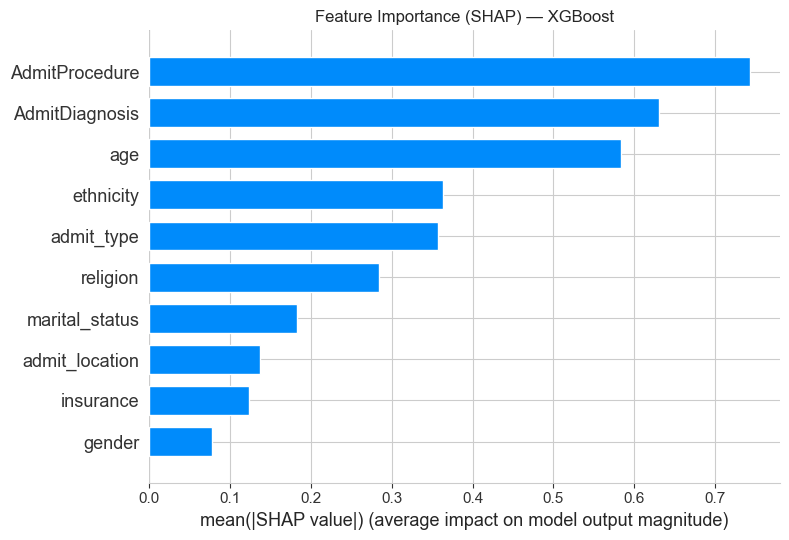

Graph save ho gaya: shap_importance.png


In [37]:
import matplotlib.pyplot as plt

# SHAP summary plot — kaunse features sabse important
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Feature Importance (SHAP) — XGBoost")
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph save ho gaya: shap_importance.png")

In [38]:
import numpy as np
import pandas as pd

# har feature ki average importance
importance = np.abs(shap_values).mean(axis=0)
feat_imp = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False).head(10)

print("=== TOP 10 SABSE IMPORTANT FEATURES ===")
print(feat_imp.to_string(index=False))

=== TOP 10 SABSE IMPORTANT FEATURES ===
       Feature  Importance
AdmitProcedure    0.743116
AdmitDiagnosis    0.630135
           age    0.583455
     ethnicity    0.363027
    admit_type    0.357241
      religion    0.284172
marital_status    0.182620
admit_location    0.137388
     insurance    0.123244
        gender    0.077570


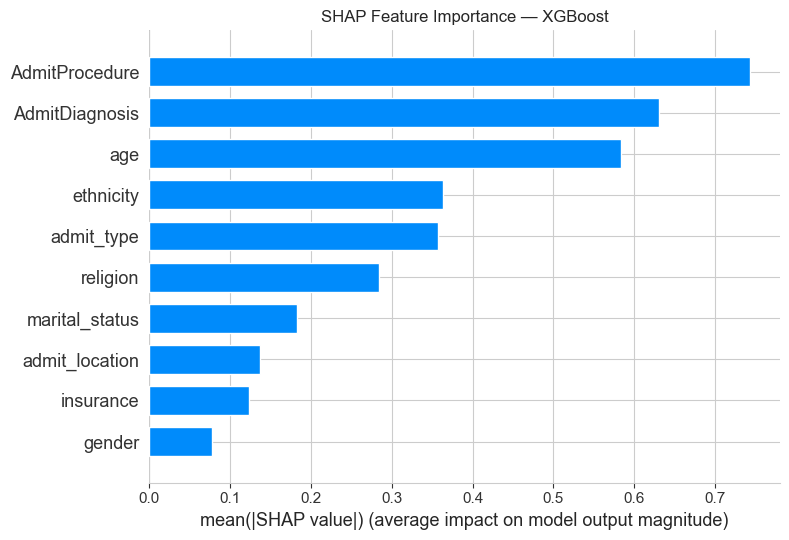

In [39]:
import shap
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Check: purana code ready hai?
print("=== Checking purana data ready hai ya nahi ===")
try:
    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)
    print("y_train shape:", y_train.shape)
    print("y_test shape:", y_test.shape)
    print("\nSab ready hai! Aage barh sakte hain.")
except NameError as e:
    print("Ye variable nahi mila:", e)
    print("Pehle 'Run All Cells' karein (Run menu se)")

=== Checking purana data ready hai ya nahi ===
X_train shape: (40692, 10)
X_test shape: (10174, 10)
y_train shape: (40692,)
y_test shape: (10174,)

Sab ready hai! Aage barh sakte hain.


In [41]:
# Missing data check
print("=== Training data mein missing values ===")
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print(missing)
    print(f"\nTotal {len(missing)} columns mein missing hai")
else:
    print("Is data mein koi missing value nahi hai (sab bhara hua)")
    print("Note: Hum aage SYNTHETIC missing banayenge (test ke liye)")

=== Training data mein missing values ===
marital_status    1889
religion           357
AdmitDiagnosis      23
dtype: int64

Total 3 columns mein missing hai


In [42]:
# Data types check
print("=== X_train ke columns ke types ===")
print(X_train.dtypes.value_counts())
print()
print("=== Konse columns text/object hain (agar koi) ===")
text_cols = X_train.select_dtypes(include='object').columns.tolist()
if text_cols:
    print(text_cols)
    print("\nYe text columns hain — encoding chahiye imputation se pehle")
else:
    print("Koi text column nahi — sab numbers hain (imputation ready)")

=== X_train ke columns ke types ===
object    9
int64     1
Name: count, dtype: int64

=== Konse columns text/object hain (agar koi) ===
['gender', 'admit_type', 'admit_location', 'AdmitDiagnosis', 'insurance', 'religion', 'marital_status', 'ethnicity', 'AdmitProcedure']

Ye text columns hain — encoding chahiye imputation se pehle


In [43]:
import numpy as np
import pandas as pd

# Copy banayein
X_train_enc2 = X_train.copy()
X_test_enc2 = X_test.copy()

text_cols = X_train.select_dtypes(include='object').columns.tolist()

for col in text_cols:
    # Train ki unique values ko number do (mapping banao)
    categories = X_train_enc2[col].dropna().astype(str).unique()
    mapping = {cat: i for i, cat in enumerate(categories)}
    
    # Apply mapping (missing NaN rahega, nayi value bhi NaN)
    X_train_enc2[col] = X_train_enc2[col].astype(str).map(mapping)
    X_test_enc2[col] = X_test_enc2[col].astype(str).map(mapping)

print("Encoding ho gaya! (tez tareeqa)")
print("\nColumn types ab:")
print(X_train_enc2.dtypes.value_counts())
print("\nTotal missing (impute karne ke liye):", int(X_train_enc2.isnull().sum().sum()))

Encoding ho gaya! (tez tareeqa)

Column types ab:
int64      7
float64    3
Name: count, dtype: int64

Total missing (impute karne ke liye): 2269


In [44]:
from sklearn.impute import SimpleImputer, KNNImputer
import pandas as pd

# Dictionary mein saare imputed versions store karenge
imputed_train = {}
imputed_test = {}

# 1. MEAN imputation
mean_imp = SimpleImputer(strategy='mean')
imputed_train['Mean'] = pd.DataFrame(mean_imp.fit_transform(X_train_enc2), columns=X_train_enc2.columns)
imputed_test['Mean'] = pd.DataFrame(mean_imp.transform(X_test_enc2), columns=X_test_enc2.columns)

# 2. MEDIAN imputation
median_imp = SimpleImputer(strategy='median')
imputed_train['Median'] = pd.DataFrame(median_imp.fit_transform(X_train_enc2), columns=X_train_enc2.columns)
imputed_test['Median'] = pd.DataFrame(median_imp.transform(X_test_enc2), columns=X_test_enc2.columns)

# 3. KNN imputation (thoda dheere — 1-2 min)
print("KNN chal raha hai... thoda intezaar karein (1-2 min)")
knn_imp = KNNImputer(n_neighbors=5)
imputed_train['KNN'] = pd.DataFrame(knn_imp.fit_transform(X_train_enc2), columns=X_train_enc2.columns)
imputed_test['KNN'] = pd.DataFrame(knn_imp.transform(X_test_enc2), columns=X_test_enc2.columns)

print("\n3 methods ho gaye!")
for method in ['Mean', 'Median', 'KNN']:
    print(f"{method}: missing = {imputed_train[method].isnull().sum().sum()}")

KNN chal raha hai... thoda intezaar karein (1-2 min)

3 methods ho gaye!
Mean: missing = 0
Median: missing = 0
KNN: missing = 0


In [45]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# 4. MICE — TEZ version (max_iter kam)
print("MICE chal raha hai... (1 min)")
mice_imp = IterativeImputer(max_iter=5, random_state=42)
imputed_train['MICE'] = pd.DataFrame(mice_imp.fit_transform(X_train_enc2), columns=X_train_enc2.columns)
imputed_test['MICE'] = pd.DataFrame(mice_imp.transform(X_test_enc2), columns=X_test_enc2.columns)
print("MICE ho gaya!")

# 5. MissForest — TEZ version (chhota forest)
print("\nMissForest chal raha hai... (2-3 min)")
missforest_imp = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, max_depth=10, random_state=42, n_jobs=-1),
    max_iter=3, random_state=42)
imputed_train['MissForest'] = pd.DataFrame(missforest_imp.fit_transform(X_train_enc2), columns=X_train_enc2.columns)
imputed_test['MissForest'] = pd.DataFrame(missforest_imp.transform(X_test_enc2), columns=X_test_enc2.columns)
print("MissForest ho gaya!")

print("\n=== Saare methods ===")
for method in imputed_train:
    print(f"{method}: missing = {imputed_train[method].isnull().sum().sum()}")
    

MICE chal raha hai... (1 min)
MICE ho gaya!

MissForest chal raha hai... (2-3 min)


C:\Users\Laptop Solutions\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MissForest ho gaya!

=== Saare methods ===
Mean: missing = 0
Median: missing = 0
KNN: missing = 0
MICE: missing = 0
MissForest: missing = 0


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

# imbalance ratio (mortality kam hai)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

def test_models(X_tr, X_te, y_tr, y_te, method_name):
    """Ek imputed dataset par 3 models chalao aur results do"""
    results = []
    
    # 1. Logistic Regression (scaling ke saath)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    lr = LogisticRegression(max_iter=1000, class_weight='balanced')
    lr.fit(X_tr_s, y_tr)
    p = lr.predict_proba(X_te_s)[:, 1]
    results.append([method_name, 'LogisticRegression', roc_auc_score(y_te, p), average_precision_score(y_te, p)])
    
    # 2. Random Forest
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    p = rf.predict_proba(X_te)[:, 1]
    results.append([method_name, 'RandomForest', roc_auc_score(y_te, p), average_precision_score(y_te, p)])
    
    # 3. XGBoost
    xgb = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
    xgb.fit(X_tr, y_tr)
    p = xgb.predict_proba(X_te)[:, 1]
    results.append([method_name, 'XGBoost', roc_auc_score(y_te, p), average_precision_score(y_te, p)])
    
    return results

print("Function ready! Ab har method par models chala sakte hain.")

Function ready! Ab har method par models chala sakte hain.


In [47]:
import pandas as pd

all_results = []

print("Models chal rahe hain... (har method 1-2 min, total 5-8 min)\n")

for method in ['Mean', 'Median', 'KNN', 'MICE', 'MissForest']:
    print(f"  {method} par models chal rahe hain...")
    res = test_models(
        imputed_train[method], imputed_test[method],
        y_train, y_test, method
    )
    all_results.extend(res)
    print(f"  {method} ho gaya!")

# Results table banao
results_df = pd.DataFrame(all_results, columns=['Imputation', 'Model', 'AUROC', 'AUPRC'])
results_df['AUROC'] = results_df['AUROC'].round(3)
results_df['AUPRC'] = results_df['AUPRC'].round(3)

print("\n=== SAARE RESULTS (Imputation x Model) ===")
print(results_df.to_string(index=False))

# Best combination
best = results_df.loc[results_df['AUROC'].idxmax()]
print(f"\n>> BEST: {best['Imputation']} + {best['Model']} (AUROC = {best['AUROC']})")

# Save for later
results_df.to_csv('imputation_model_results.csv', index=False)
print("\nResults save ho gaye: imputation_model_results.csv")

Models chal rahe hain... (har method 1-2 min, total 5-8 min)

  Mean par models chal rahe hain...
  Mean ho gaya!
  Median par models chal rahe hain...
  Median ho gaya!
  KNN par models chal rahe hain...
  KNN ho gaya!
  MICE par models chal rahe hain...
  MICE ho gaya!
  MissForest par models chal rahe hain...
  MissForest ho gaya!

=== SAARE RESULTS (Imputation x Model) ===
Imputation              Model  AUROC  AUPRC
      Mean LogisticRegression  0.643  0.170
      Mean       RandomForest  0.736  0.278
      Mean            XGBoost  0.777  0.343
    Median LogisticRegression  0.643  0.170
    Median       RandomForest  0.738  0.276
    Median            XGBoost  0.772  0.338
       KNN LogisticRegression  0.642  0.170
       KNN       RandomForest  0.737  0.277
       KNN            XGBoost  0.771  0.331
      MICE LogisticRegression  0.643  0.170
      MICE       RandomForest  0.738  0.284
      MICE            XGBoost  0.769  0.332
MissForest LogisticRegression  0.643  0.170
Miss

Native XGBoost chal raha hai...
Native XGBoost (tuned): AUROC = 0.755, AUPRC = 0.317


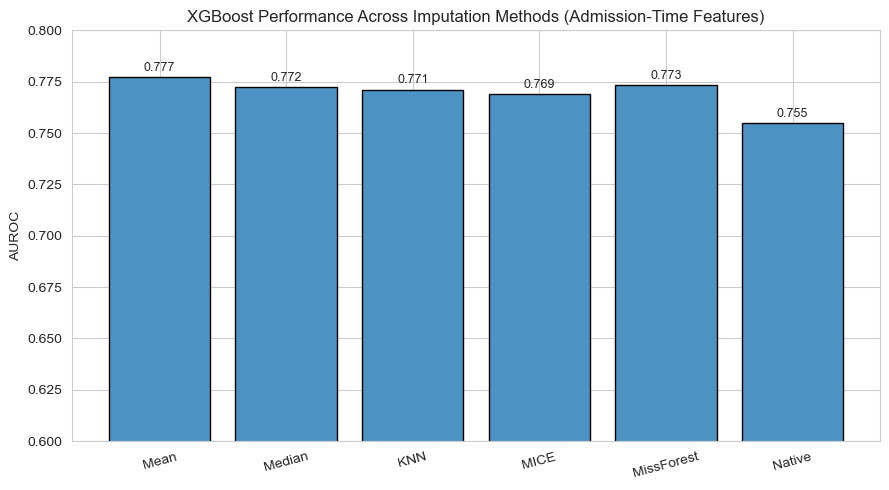


Graph save: imputation_comparison.png


In [48]:
# 6. NATIVE — XGBoost bina imputation (original missing data par)
print("Native XGBoost chal raha hai...")

# FIX: xgb_best jaisa hi tuned config use kar rahe hain — taake MICE vs Native
# comparison fair ho (dono ko same hyperparameters milen, sirf imputation ka farq measure ho)
xgb_native = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                            subsample=1.0, colsample_bytree=1.0,
                            scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_native.fit(X_train_enc2, y_train)  # missing wala data (X_train_enc2)

p = xgb_native.predict_proba(X_test_enc2)[:, 1]
native_auroc = roc_auc_score(y_test, p)
native_auprc = average_precision_score(y_test, p)

# Native ko results mein add karo
all_results.append(['Native', 'XGBoost (tuned)', round(native_auroc,3), round(native_auprc,3)])
results_df = pd.DataFrame(all_results, columns=['Imputation', 'Model', 'AUROC', 'AUPRC'])
print(f"Native XGBoost (tuned): AUROC = {native_auroc:.3f}, AUPRC = {native_auprc:.3f}")

# Graph banao (sirf XGBoost ke results, har imputation)
xgb_only = results_df[results_df['Model'].str.contains('XGBoost')].copy()

plt.figure(figsize=(9,5))
plt.bar(xgb_only['Imputation'], xgb_only['AUROC'], color='#4C92C3', edgecolor='black')
plt.ylim(0.60, 0.80)
plt.ylabel('AUROC')
plt.title('XGBoost Performance Across Imputation Methods (Admission-Time Features)')
plt.xticks(rotation=15)
for i, v in enumerate(xgb_only['AUROC']):
    plt.text(i, v+0.003, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('imputation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGraph save: imputation_comparison.png")

In [49]:
# Check: purana missingness function hai?
print("=== Synthetic missingness function check ===")

# common naam try karte hain
import types
found = []
for name in dir():
    obj = eval(name)
    if isinstance(obj, types.FunctionType) and ('miss' in name.lower() or 'mcar' in name.lower() or 'mnar' in name.lower()):
        found.append(name)

if found:
    print("Ye missingness functions mile:", found)
else:
    print("Koi missingness function nahi mila is naam se.")
    print("Koi baat nahi — main naya complete function dunga (MCAR + MAR + MNAR teeno).")

=== Synthetic missingness function check ===
Ye missingness functions mile: ['add_missing']


In [50]:
import inspect
print(inspect.getsource(add_missing))

def add_missing(data, rate, mechanism='MCAR', random_state=42):
    rng = np.random.RandomState(random_state)
    df_miss = data.copy()
    num_cols = df_miss.select_dtypes(include=[np.number]).columns.tolist()

    mar_driver = 'age' if 'age' in df_miss.columns else num_cols[0]
    driver_median = df_miss[mar_driver].median()

    for col in num_cols:
        if mechanism == 'MCAR':
            mask = rng.rand(len(df_miss)) < rate
        elif mechanism == 'MAR':
            prob = np.where(df_miss[mar_driver] > driver_median, rate*1.5, rate*0.5)
            mask = rng.rand(len(df_miss)) < prob
        else:  # MNAR
            median = df_miss[col].median()
            prob = np.where(df_miss[col] > median, rate*1.5, rate*0.5)
            mask = rng.rand(len(df_miss)) < prob
        df_miss.loc[mask, col] = np.nan
    return df_miss



In [51]:
from sklearn.metrics import (f1_score, recall_score, precision_score, 
                             brier_score_loss, confusion_matrix, roc_auc_score, 
                             average_precision_score)

# Best combo: MICE + XGBoost
X_tr_best = imputed_train['MICE']
X_te_best = imputed_test['MICE']

# FIX: genuinely tuned config use kar rahe hain (jo RandomizedSearchCV se mila tha),
# pehle ye sirf n_estimators=100 tha, baaki default — jo "tuned" claim se match nahi karta tha
xgb_best = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                          subsample=1.0, colsample_bytree=1.0,
                          scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_best.fit(X_tr_best, y_train)

# Predictions
proba = xgb_best.predict_proba(X_te_best)[:, 1]
pred = (proba >= 0.5).astype(int)

# Confusion matrix se metrics
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

sensitivity = tp / (tp + fn)   # recall (deaths pakadna)
specificity = tn / (tn + fp)   # survivors pakadna
f1 = f1_score(y_test, pred)
precision = precision_score(y_test, pred)
brier = brier_score_loss(y_test, proba)   # calibration (kam = behtar)
auroc = roc_auc_score(y_test, proba)
auprc = average_precision_score(y_test, proba)

print("=== BEST MODEL METRICS (MICE + Tuned XGBoost) ===")
print(f"AUROC:        {auroc:.3f}")
print(f"AUPRC:        {auprc:.3f}")
print(f"Sensitivity:  {sensitivity:.3f}  (deaths sahi pakde)")
print(f"Specificity:  {specificity:.3f}  (survivors sahi pakde)")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"Brier Score:  {brier:.3f}  (kam = behtar calibration)")

=== BEST MODEL METRICS (MICE + Tuned XGBoost) ===
AUROC:        0.786
AUPRC:        0.339
Sensitivity:  0.700  (deaths sahi pakde)
Specificity:  0.729  (survivors sahi pakde)
Precision:    0.249
F1-score:     0.368
Brier Score:  0.182  (kam = behtar calibration)


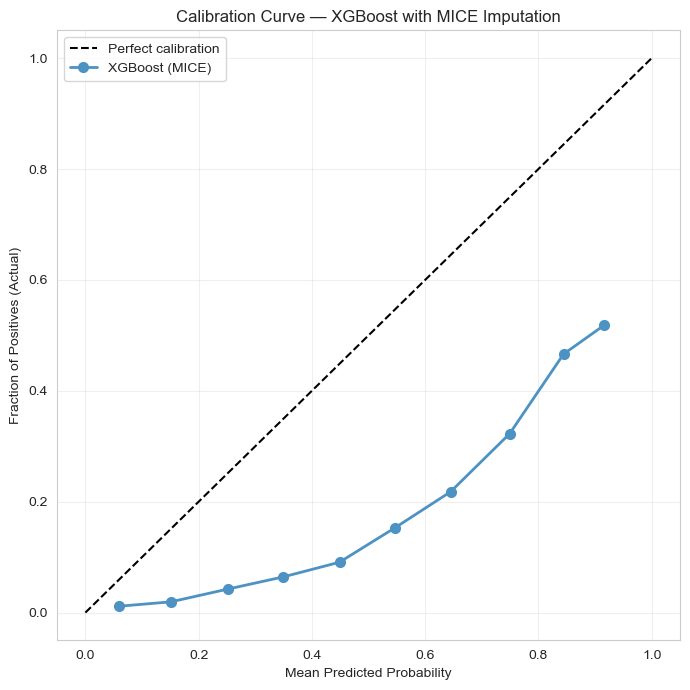

Calibration curve save ho gaya: calibration_curve.png

Brier Score: 0.182 (kam = behtar calibration)


In [52]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Best model ki probabilities (proba pehle se hai Cell M se)
# Agar na ho to dobara nikaal lo:
proba = xgb_best.predict_proba(X_te_best)[:, 1]

# Calibration curve calculate karo
prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10)
brier = brier_score_loss(y_test, proba)   # asal Brier score, hardcoded nahi

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', color='#4C92C3', 
         linewidth=2, markersize=7, label='XGBoost (MICE)')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Calibration Curve — XGBoost with MICE Imputation')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Calibration curve save ho gaya: calibration_curve.png")
print(f"\nBrier Score: {brier:.3f} (kam = behtar calibration)")   # FIXED — ab asal value print hogi

In [53]:
# Sensitive attributes check
print("=== Fairness ke liye attributes check ===")

# Pehle dekho sens_test mojood hai?
try:
    print("sens_test columns:", list(sens_test.columns))
    print("sens_test shape:", sens_test.shape)
    print("\nMil gaya! Ye attributes fairness ke liye use honge.")
except NameError:
    print("sens_test nahi mila. Original df se nikalna parega.")
    print("Original df columns:", list(df.columns) if 'df' in dir() else "df bhi nahi mila")

=== Fairness ke liye attributes check ===
sens_test columns: ['gender', 'ethnicity', 'insurance', 'marital_status', 'age', 'age_band']
sens_test shape: (10174, 6)

Mil gaya! Ye attributes fairness ke liye use honge.


In [54]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def fairness_metrics(y_true, y_pred, sensitive):
    """Ek attribute ke liye fairness metrics nikalta hai"""
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    sensitive = np.array(sensitive).ravel()
    
    groups = pd.unique(sensitive[~pd.isnull(sensitive)])
    stats = {}
    
    for g in groups:
        mask = (sensitive == g)
        if mask.sum() < 30:   # bohat chhote groups skip
            continue
        yt, yp = y_true[mask], y_pred[mask]
        if len(np.unique(yt)) < 2:  # agar ek hi class ho
            continue
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
        
        tpr = tp/(tp+fn) if (tp+fn)>0 else 0   # recall / sensitivity
        fpr = fp/(fp+tn) if (fp+tn)>0 else 0
        fnr = fn/(fn+tp) if (fn+tp)>0 else 0
        ppr = (tp+fp)/len(yt)                  # positive prediction rate
        
        stats[g] = {'N': int(mask.sum()), 'TPR': tpr, 'FPR': fpr, 'FNR': fnr, 'PPR': ppr}
    
    if len(stats) < 2:
        return None, None
    
    sdf = pd.DataFrame(stats).T
    # Gaps (max - min)
    gaps = {
        'Demographic_Parity_Diff': sdf['PPR'].max() - sdf['PPR'].min(),
        'Equal_Opportunity_Diff': sdf['TPR'].max() - sdf['TPR'].min(),
        'Equalized_Odds_Diff': max(sdf['TPR'].max()-sdf['TPR'].min(), sdf['FPR'].max()-sdf['FPR'].min()),
        'FNR_Gap': sdf['FNR'].max() - sdf['FNR'].min(),
    }
    return sdf.round(3), gaps

print("Fairness function ready!")

Fairness function ready!


In [55]:
import pandas as pd

# Best model ke predictions (MICE + XGBoost)
proba = xgb_best.predict_proba(X_te_best)[:, 1]
pred = (proba >= 0.5).astype(int)

# Sensitive attributes (sens_test se)
attributes = ['gender', 'insurance', 'age_band', 'ethnicity']

fairness_summary = []

for attr in attributes:
    print(f"\n{'='*50}")
    print(f"=== {attr.upper()} ===")
    sdf, gaps = fairness_metrics(y_test, pred, sens_test[attr])
    
    if sdf is not None:
        print(sdf.to_string())
        print(f"\nGaps:")
        for k, v in gaps.items():
            print(f"  {k}: {v:.3f}")
        # summary ke liye
        row = {'Attribute': attr}
        row.update({k: round(v,3) for k,v in gaps.items()})
        fairness_summary.append(row)
    else:
        print("Is attribute par metrics nahi nikal sakе (groups kam)")

# Summary table
print(f"\n\n{'='*50}")
print("=== FAIRNESS SUMMARY (saare attributes) ===")
fair_df = pd.DataFrame(fairness_summary)
print(fair_df.to_string(index=False))
fair_df.to_csv('fairness_metrics.csv', index=False)
print("\nSave: fairness_metrics.csv")


=== GENDER ===
        N    TPR    FPR    FNR    PPR
M  5757.0  0.693  0.249  0.307  0.296
F  4417.0  0.709  0.300  0.291  0.350

Gaps:
  Demographic_Parity_Diff: 0.054
  Equal_Opportunity_Diff: 0.017
  Equalized_Odds_Diff: 0.051
  FNR_Gap: 0.017

=== INSURANCE ===
                 N    TPR    FPR    FNR    PPR
Medicare    5655.0  0.761  0.374  0.239  0.427
Private     3224.0  0.578  0.146  0.422  0.181
Medicaid     914.0  0.595  0.156  0.405  0.191
Government   261.0  0.333  0.129  0.667  0.138
Self Pay     120.0  0.583  0.281  0.417  0.342

Gaps:
  Demographic_Parity_Diff: 0.289
  Equal_Opportunity_Diff: 0.427
  Equalized_Odds_Diff: 0.427
  FNR_Gap: 0.427

=== AGE_BAND ===
            N    TPR    FPR    FNR    PPR
75+    2398.0  0.830  0.494  0.170  0.550
60-75  3157.0  0.675  0.235  0.325  0.283
<40    1118.0  0.315  0.090  0.685  0.101
40-60  3501.0  0.639  0.222  0.361  0.265

Gaps:
  Demographic_Parity_Diff: 0.449
  Equal_Opportunity_Diff: 0.515
  Equalized_Odds_Diff: 0.515
  FN

In [56]:
import shap

# Best model: MICE + XGBoost (xgb_best pehle se trained hai)
print("SHAP calculate ho raha hai... (1-2 min)")

# Sample lein (speed ke liye — pure test se 2000 rows)
X_sample = X_te_best.sample(n=2000, random_state=42)

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_sample)

print("SHAP values ready!")
print("Shape:", shap_values.shape)

# Top features (mean absolute SHAP)
import numpy as np
import pandas as pd
mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Mean_SHAP': mean_shap
}).sort_values('Mean_SHAP', ascending=False)

print("\n=== TOP 10 FEATURES (SHAP) ===")
print(shap_importance.head(10).to_string(index=False))

SHAP calculate ho raha hai... (1-2 min)
SHAP values ready!
Shape: (2000, 10)

=== TOP 10 FEATURES (SHAP) ===
       Feature  Mean_SHAP
AdmitProcedure   0.551470
    admit_type   0.295280
           age   0.273005
AdmitDiagnosis   0.200737
      religion   0.143841
     ethnicity   0.102347
marital_status   0.099745
admit_location   0.075899
     insurance   0.075575
        gender   0.004995


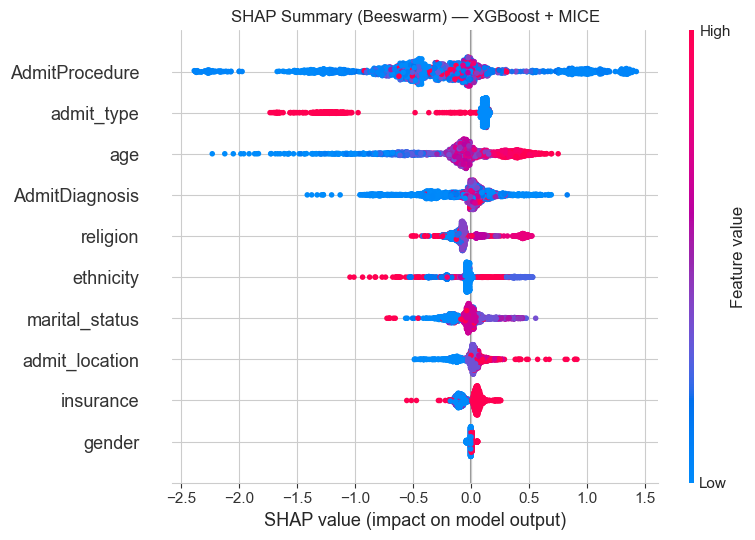

1. Beeswarm save: shap_beeswarm.png


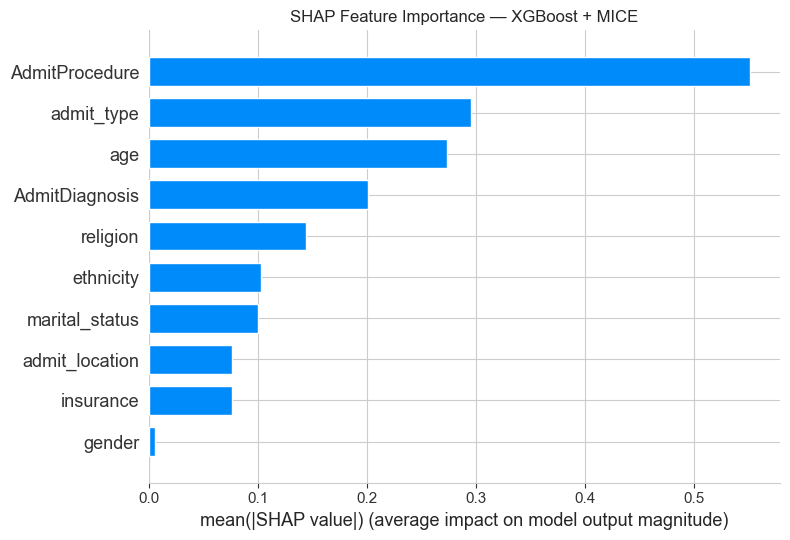

2. Bar save: shap_bar.png


In [57]:
import shap
import matplotlib.pyplot as plt

# 1. BEESWARM plot (har patient ke dots — sabse "SHAP jaisा")
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary (Beeswarm) — XGBoost + MICE")
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("1. Beeswarm save: shap_beeswarm.png")

# 2. BAR plot (feature importance ranking)
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost + MICE")
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("2. Bar save: shap_bar.png")

<Figure size 800x500 with 0 Axes>

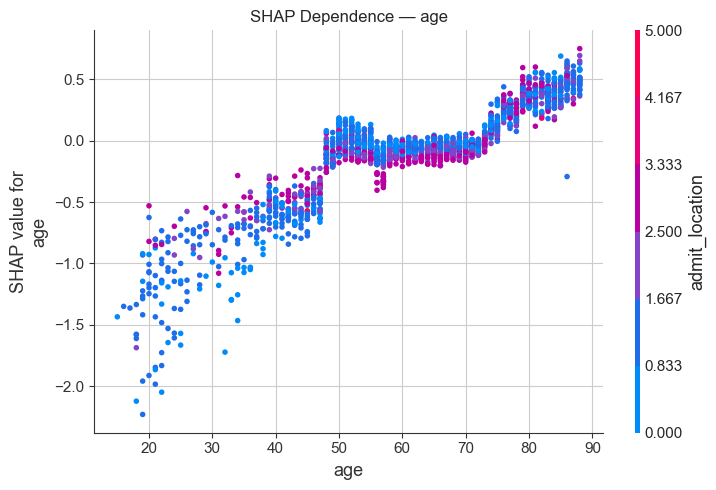

Save: shap_dependence_age.png


<Figure size 800x500 with 0 Axes>

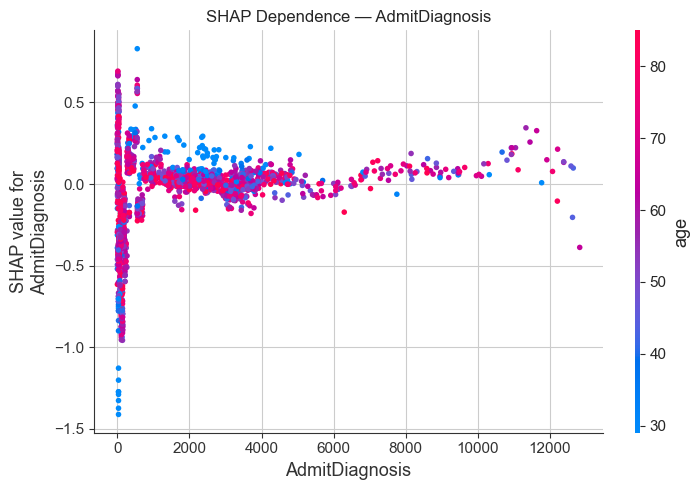

Save: shap_dependence_AdmitDiagnosis.png


<Figure size 800x500 with 0 Axes>

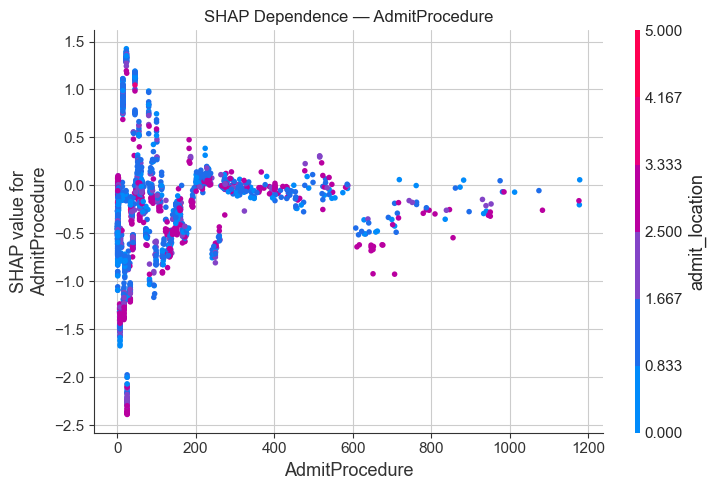

Save: shap_dependence_AdmitProcedure.png


In [58]:
import shap
import matplotlib.pyplot as plt

# Dependence plots — 3 features (jo supervisor ne maange)
features_to_plot = ['age', 'AdmitDiagnosis', 'AdmitProcedure']

for feat in features_to_plot:
    if feat in X_sample.columns:
        plt.figure()
        shap.dependence_plot(feat, shap_values, X_sample, show=False)
        plt.title(f"SHAP Dependence — {feat}")
        plt.tight_layout()
        plt.savefig(f'shap_dependence_{feat}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Save: shap_dependence_{feat}.png")
    else:
        print(f"{feat} column nahi mila, skip")

Survived example: actual=0, predicted probability=0.027
Expired example: actual=1, predicted probability=0.709


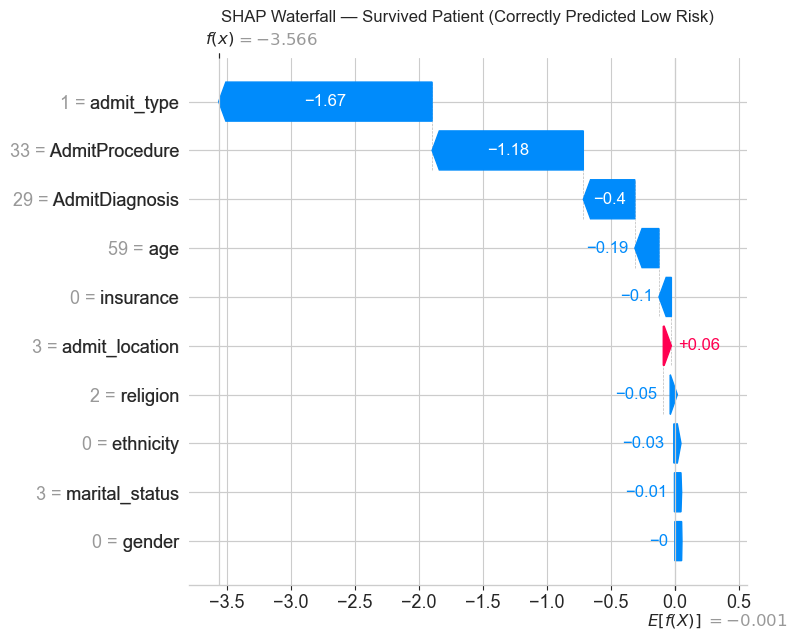

1. Survived save: shap_waterfall_survived.png


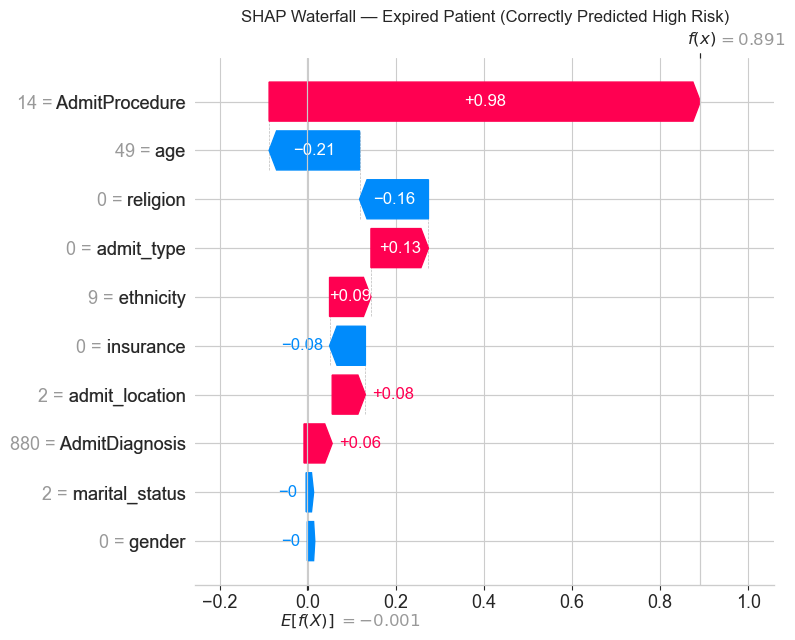

2. Expired save: shap_waterfall_expired.png


In [59]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Explainer object
explainer2 = shap.TreeExplainer(xgb_best)
shap_exp = explainer2(X_sample)

# y_test ko X_sample ke SAME index se align karo (positional, naam se nahi)
y_sample = y_test.reset_index(drop=True).iloc[
    [X_te_best.index.get_loc(i) for i in X_sample.index]
].values

# Model ki predicted probability bhi X_sample ke liye nikaal lo
proba_sample = xgb_best.predict_proba(X_sample)[:, 1]

# ===== FIX: sirf actual label nahi, model ki correct prediction bhi check karo =====
# Survived: actual=0 AUR model ne bhi sahi se LOW risk predict kiya (true negative)
survived_mask = (y_sample == 0) & (proba_sample < 0.3)
# Expired: actual=1 AUR model ne bhi sahi se HIGH risk predict kiya (true positive)
expired_mask = (y_sample == 1) & (proba_sample > 0.7)

if survived_mask.sum() == 0 or expired_mask.sum() == 0:
    print("Warning: strict threshold se patient nahi mila, purana tareeqa use ho raha")
    survived_idx = int(np.where(y_sample == 0)[0][0])
    expired_idx = int(np.where(y_sample == 1)[0][0])
else:
    survived_idx = int(np.where(survived_mask)[0][0])
    expired_idx = int(np.where(expired_mask)[0][0])

print(f"Survived example: actual=0, predicted probability={proba_sample[survived_idx]:.3f}")
print(f"Expired example: actual=1, predicted probability={proba_sample[expired_idx]:.3f}")

# Survived patient
plt.figure()
shap.plots.waterfall(shap_exp[survived_idx], show=False)
plt.title("SHAP Waterfall — Survived Patient (Correctly Predicted Low Risk)")
plt.tight_layout()
plt.savefig('shap_waterfall_survived.png', dpi=150, bbox_inches='tight')
plt.show()
print("1. Survived save: shap_waterfall_survived.png")

# Expired patient
plt.figure()
shap.plots.waterfall(shap_exp[expired_idx], show=False)
plt.title("SHAP Waterfall — Expired Patient (Correctly Predicted High Risk)")
plt.tight_layout()
plt.savefig('shap_waterfall_expired.png', dpi=150, bbox_inches='tight')
plt.show()
print("2. Expired save: shap_waterfall_expired.png")

In [60]:
import shap
import numpy as np
import pandas as pd

print("SHAP stability check ho raha hai... (har method 1-2 min)\n")

stability = {}

for method in ['Mean', 'Median', 'KNN', 'MICE', 'MissForest']:
    print(f"  {method} ka SHAP...")
    # Us method ke data par model train karo
    Xtr = imputed_train[method]
    Xte = imputed_test[method]
    
    model_m = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, 
                            random_state=42, eval_metric='logloss')
    model_m.fit(Xtr, y_train)
    
    # SHAP (sample par)
    Xs = Xte.sample(n=1000, random_state=42)
    expl = shap.TreeExplainer(model_m)
    sv = expl.shap_values(Xs)
    
    # Mean absolute SHAP per feature
    mean_sv = np.abs(sv).mean(axis=0)
    stability[method] = pd.Series(mean_sv, index=Xs.columns)

# Saare methods ka comparison table
stab_df = pd.DataFrame(stability)
stab_df['Average'] = stab_df.mean(axis=1)
stab_df = stab_df.sort_values('Average', ascending=False)

print("\n=== TOP 10 FEATURES — har imputation method (SHAP importance) ===")
print(stab_df.head(10).round(3).to_string())

stab_df.to_csv('shap_stability.csv')
print("\nSave: shap_stability.csv")

SHAP stability check ho raha hai... (har method 1-2 min)

  Mean ka SHAP...
  Median ka SHAP...
  KNN ka SHAP...
  MICE ka SHAP...
  MissForest ka SHAP...

=== TOP 10 FEATURES — har imputation method (SHAP importance) ===
                 Mean  Median    KNN   MICE  MissForest  Average
AdmitProcedure  0.747   0.752  0.731  0.752       0.731    0.742
age             0.416   0.406  0.421  0.425       0.428    0.419
AdmitDiagnosis  0.306   0.399  0.346  0.337       0.321    0.342
admit_type      0.307   0.343  0.313  0.317       0.303    0.317
religion        0.200   0.206  0.207  0.188       0.188    0.198
ethnicity       0.149   0.156  0.154  0.155       0.151    0.153
marital_status  0.140   0.123  0.139  0.143       0.132    0.135
admit_location  0.120   0.126  0.124  0.118       0.124    0.123
insurance       0.115   0.137  0.114  0.098       0.110    0.115
gender          0.040   0.039  0.038  0.043       0.043    0.041

Save: shap_stability.csv


In [61]:
# ===== FAIRNESS ACROSS SAARI 6 MISSING-DATA STRATEGIES + BOOTSTRAP CI =====
# (supervisor: "reviewers will not accept deferral" — har strategy ke liye CI bhi chahiye)

import pandas as pd
import numpy as np
from xgboost import XGBClassifier

all_fairness_results = []
attributes = ['gender', 'insurance', 'age_band', 'ethnicity']

methods_data = {
    'Mean':       (imputed_train['Mean'],       imputed_test['Mean']),
    'Median':     (imputed_train['Median'],     imputed_test['Median']),
    'KNN':        (imputed_train['KNN'],        imputed_test['KNN']),
    'MICE':       (imputed_train['MICE'],       imputed_test['MICE']),
    'MissForest': (imputed_train['MissForest'], imputed_test['MissForest']),
    'Native':     (X_train_enc2,                X_test_enc2),
}

y_true_arr = y_test.reset_index(drop=True).values
n_boot = 1000
rng = np.random.RandomState(42)
n_test = len(y_true_arr)

for method_name, (Xtr, Xte) in methods_data.items():
    print(f"\n{'='*55}")
    print(f"{method_name} ka model train ho raha hai...")

    model = XGBClassifier(n_estimators=100, scale_pos_weight=ratio,
                           random_state=42, eval_metric='logloss')
    model.fit(Xtr, y_train)

    proba = model.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)

    for attr in attributes:
        sdf, gaps = fairness_metrics(y_test, pred, sens_test[attr])
        if gaps is None:
            print(f"  {attr}: groups kam hain, skip ho gaya")
            continue

        # ---- Bootstrap CI: resample test-set indices 1000 baar, har baar FNR gap nikalo ----
        sens_attr_arr = sens_test[attr].reset_index(drop=True).values
        boot_fnr_gaps = []
        for i in range(n_boot):
            idx = rng.choice(n_test, n_test, replace=True)
            _, boot_gaps = fairness_metrics(y_true_arr[idx], pred[idx], sens_attr_arr[idx])
            if boot_gaps is not None:
                boot_fnr_gaps.append(boot_gaps['FNR_Gap'])

        if len(boot_fnr_gaps) >= 50:
            ci_low, ci_high = np.percentile(boot_fnr_gaps, [2.5, 97.5])
        else:
            ci_low, ci_high = np.nan, np.nan

        row = {'Imputation': method_name, 'Attribute': attr}
        row.update({k: round(v, 3) for k, v in gaps.items()})
        row['FNR_Gap_CI_low'] = round(ci_low, 3)
        row['FNR_Gap_CI_high'] = round(ci_high, 3)
        all_fairness_results.append(row)
        print(f"  {attr}: FNR_Gap={gaps['FNR_Gap']:.3f}  CI=[{ci_low:.3f}, {ci_high:.3f}]")

# ===== Final comparison table =====
fairness_all_methods_df = pd.DataFrame(all_fairness_results)
print("\n\n" + "="*55)
print("=== FAIRNESS GAPS ACROSS ALL 6 IMPUTATION STRATEGIES (with 95% CI) ===")
print(fairness_all_methods_df.to_string(index=False))

fairness_all_methods_df.to_csv('fairness_all_imputation_methods.csv', index=False)
print("\nSave: fairness_all_imputation_methods.csv")

fnr_pivot = fairness_all_methods_df.pivot(index='Imputation', columns='Attribute', values='FNR_Gap')
print("\n=== FNR GAP PIVOT (thesis Table ke liye ready) ===")
print(fnr_pivot.round(3).to_string())
fnr_pivot.to_csv('fairness_fnr_pivot_all_methods.csv')
print("\nSave: fairness_fnr_pivot_all_methods.csv")


Mean ka model train ho raha hai...
  gender: FNR_Gap=0.038  CI=[0.002, 0.095]
  insurance: FNR_Gap=0.415  CI=[0.201, 0.664]
  age_band: FNR_Gap=0.463  CI=[0.339, 0.583]
  ethnicity: FNR_Gap=0.624  CI=[0.352, 1.000]

Median ka model train ho raha hai...
  gender: FNR_Gap=0.012  CI=[0.001, 0.073]
  insurance: FNR_Gap=0.301  CI=[0.151, 0.570]
  age_band: FNR_Gap=0.396  CI=[0.259, 0.525]
  ethnicity: FNR_Gap=0.667  CI=[0.395, 1.000]

KNN ka model train ho raha hai...
  gender: FNR_Gap=0.019  CI=[0.001, 0.077]
  insurance: FNR_Gap=0.346  CI=[0.188, 0.616]
  age_band: FNR_Gap=0.403  CI=[0.259, 0.525]
  ethnicity: FNR_Gap=0.625  CI=[0.378, 1.000]

MICE ka model train ho raha hai...
  gender: FNR_Gap=0.015  CI=[0.001, 0.067]
  insurance: FNR_Gap=0.270  CI=[0.168, 0.528]
  age_band: FNR_Gap=0.464  CI=[0.350, 0.583]
  ethnicity: FNR_Gap=0.625  CI=[0.357, 1.000]

MissForest ka model train ho raha hai...
  gender: FNR_Gap=0.023  CI=[0.001, 0.082]
  insurance: FNR_Gap=0.230  CI=[0.167, 0.525]
  ag

In [62]:
# ===== N-DEATHS PER SUBGROUP (supervisor ka concern: "Under-40 FNR of 0.778 is 
# uninterpretable without knowing it rests on perhaps a few dozen events") =====

import pandas as pd
import numpy as np

# Best model (tuned) ki predictions
proba = xgb_best.predict_proba(X_te_best)[:, 1]
pred = (proba >= 0.5).astype(int)

y_true_arr = y_test.reset_index(drop=True).values
attributes = ['gender', 'insurance', 'age_band', 'ethnicity']

for attr in attributes:
    print(f"\n{'='*60}")
    print(f"=== {attr.upper()} — N, Deaths, Sensitivity, FNR ===")
    
    sens_arr = sens_test[attr].reset_index(drop=True).values
    groups = pd.unique(sens_arr[~pd.isnull(sens_arr)])
    
    rows = []
    for g in groups:
        mask = (sens_arr == g)
        if mask.sum() < 30:
            continue
        yt = y_true_arr[mask]
        yp = pred[mask]
        
        n_total = mask.sum()
        n_deaths = int(yt.sum())          # actual deaths in is group mein
        
        tp = int(((yt == 1) & (yp == 1)).sum())
        fn = int(((yt == 1) & (yp == 0)).sum())
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fnr = fn / (tp + fn) if (tp + fn) > 0 else np.nan
        
        rows.append({
            'Group': g, 'N': n_total, 'N_deaths': n_deaths,
            'Sensitivity': round(sensitivity, 3), 'FNR': round(fnr, 3)
        })
    
    result_df = pd.DataFrame(rows).sort_values('N', ascending=False)
    print(result_df.to_string(index=False))
    result_df.to_csv(f'ndeaths_{attr}.csv', index=False)

print("\n\nSaari CSV files save ho gayin: ndeaths_gender.csv, ndeaths_insurance.csv, ndeaths_age_band.csv, ndeaths_ethnicity.csv")


=== GENDER — N, Deaths, Sensitivity, FNR ===
Group    N  N_deaths  Sensitivity   FNR
    M 5757       618        0.693 0.307
    F 4417       540        0.709 0.291

=== INSURANCE — N, Deaths, Sensitivity, FNR ===
     Group    N  N_deaths  Sensitivity   FNR
  Medicare 5655       785        0.761 0.239
   Private 3224       263        0.578 0.422
  Medicaid  914        74        0.595 0.405
Government  261        12        0.333 0.667
  Self Pay  120        24        0.583 0.417

=== AGE_BAND — N, Deaths, Sensitivity, FNR ===
Group    N  N_deaths  Sensitivity   FNR
40-60 3501       363        0.639 0.361
60-75 3157       342        0.675 0.325
  75+ 2398       399        0.830 0.170
  <40 1118        54        0.315 0.685

=== ETHNICITY — N, Deaths, Sensitivity, FNR ===
                         Group    N  N_deaths  Sensitivity   FNR
                         WHITE 7202       791        0.695 0.305
        BLACK/AFRICAN AMERICAN  941        93        0.495 0.505
         UNKNOWN/NOT SP

In [63]:
import sklearn, xgboost, pandas, numpy, scipy
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)

scikit-learn: 1.7.2
xgboost: 3.2.0
pandas: 2.3.3
numpy: 2.3.5
scipy: 1.15.3


In [64]:
import numpy as np
from sklearn.metrics import roc_auc_score

print("Bootstrap CI calculate ho raha hai... (1-2 min)")

# Best model predictions
proba = xgb_best.predict_proba(X_te_best)[:, 1]
y_true = y_test.reset_index(drop=True).values
proba = np.array(proba)

# Bootstrap (1000 baar resample)
rng = np.random.RandomState(42)
n = len(y_true)
boot_aurocs = []

for i in range(1000):
    idx = rng.choice(n, n, replace=True)
    if len(np.unique(y_true[idx])) < 2:
        continue
    boot_aurocs.append(roc_auc_score(y_true[idx], proba[idx]))

boot_aurocs = np.array(boot_aurocs)

# NAYE NAAM — taake Cell 61 ke ci_low/ci_high se clash na ho
ci_low_overall = np.percentile(boot_aurocs, 2.5)
ci_high_overall = np.percentile(boot_aurocs, 97.5)
mean_auroc = roc_auc_score(y_true, proba)

print(f"\n=== AUROC with 95% Confidence Interval ===")
print(f"AUROC: {mean_auroc:.3f}")
print(f"95% CI: [{ci_low_overall:.3f} - {ci_high_overall:.3f}]")
print(f"\nMatlab: AUROC {mean_auroc:.3f} hai, aur 95% yaqeen ke saath")
print(f"ye {ci_low_overall:.3f} se {ci_high_overall:.3f} ke beech hai")

Bootstrap CI calculate ho raha hai... (1-2 min)

=== AUROC with 95% Confidence Interval ===
AUROC: 0.786
95% CI: [0.773 - 0.799]

Matlab: AUROC 0.786 hai, aur 95% yaqeen ke saath
ye 0.773 se 0.799 ke beech hai


In [65]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy import stats

print("Statistical tests chal rahe hain...\n")

# 2 models: MICE+XGBoost (best) vs Native XGBoost
proba_mice = xgb_best.predict_proba(X_te_best)[:, 1]
proba_native = xgb_native.predict_proba(X_test_enc2)[:, 1]
y_true = y_test.reset_index(drop=True).values

proba_mice = np.array(proba_mice)
proba_native = np.array(proba_native)

# === 1. Bootstrap test for AUROC difference (DeLong jaisा) ===
rng = np.random.RandomState(42)
n = len(y_true)
diffs = []
for i in range(1000):
    idx = rng.choice(n, n, replace=True)
    if len(np.unique(y_true[idx])) < 2:
        continue
    a = roc_auc_score(y_true[idx], proba_mice[idx])
    b = roc_auc_score(y_true[idx], proba_native[idx])
    diffs.append(a - b)
diffs = np.array(diffs)
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])

print("=== AUROC Difference: MICE vs Native ===")
print(f"AUROC MICE:   {roc_auc_score(y_true, proba_mice):.3f}")
print(f"AUROC Native: {roc_auc_score(y_true, proba_native):.3f}")
print(f"Difference 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
if ci_low > 0:
    print(">> MICE significantly behtar (CI mein 0 nahi)")
else:
    print(">> Farq significant nahi (CI mein 0 hai) — dono barabar")

# === 2. McNemar test (classification errors) ===
from statsmodels.stats.contingency_tables import mcnemar
pred_mice = (proba_mice >= 0.5).astype(int)
pred_native = (proba_native >= 0.5).astype(int)

# Contingency: dono sahi, ek sahi ek galat, etc.
correct_mice = (pred_mice == y_true)
correct_native = (pred_native == y_true)
table = [[np.sum(correct_mice & correct_native), np.sum(correct_mice & ~correct_native)],
         [np.sum(~correct_mice & correct_native), np.sum(~correct_mice & ~correct_native)]]
result = mcnemar(table, exact=False, correction=True)

print(f"\n=== McNemar Test (classification errors) ===")
print(f"p-value: {result.pvalue:.4f}")
if result.pvalue < 0.05:
    print(">> Dono models ki errors mein significant farq hai")
else:
    print(">> Dono models ki errors barabar (farq significant nahi)")

Statistical tests chal rahe hain...

=== AUROC Difference: MICE vs Native ===
AUROC MICE:   0.786
AUROC Native: 0.755
Difference 95% CI: [0.0211, 0.0401]
>> MICE significantly behtar (CI mein 0 nahi)

=== McNemar Test (classification errors) ===
p-value: 0.0000
>> Dono models ki errors mein significant farq hai


In [66]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import numpy as np

print("Cross-validation chal rahi hai... (3-5 min)\n")

# Best data: MICE
X_cv = imputed_train['MICE']
y_cv = y_train

# 3 seeds par 5-fold CV
all_scores = []
for seed in [42, 1, 2]:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    # FIX: xgb_best jaisa hi tuned config use kar rahe hain (n_estimators=100 tha, ab tuned)
    model = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                          subsample=1.0, colsample_bytree=1.0,
                          scale_pos_weight=ratio, random_state=seed, eval_metric='logloss')
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='roc_auc')
    all_scores.extend(scores)
    print(f"  Seed {seed}: AUROC = {scores.mean():.3f}")

all_scores = np.array(all_scores)
print(f"\n=== CROSS-VALIDATED AUROC (XGBoost + MICE, tuned) ===")
print(f"Mean AUROC: {all_scores.mean():.3f} +/- {all_scores.std():.3f}")
print(f"Range: {all_scores.min():.3f} to {all_scores.max():.3f}")
print(f"Total folds: {len(all_scores)} (3 seeds x 5 folds)")

Cross-validation chal rahi hai... (3-5 min)

  Seed 42: AUROC = 0.780
  Seed 1: AUROC = 0.781
  Seed 2: AUROC = 0.781

=== CROSS-VALIDATED AUROC (XGBoost + MICE, tuned) ===
Mean AUROC: 0.781 +/- 0.006
Range: 0.767 to 0.789
Total folds: 15 (3 seeds x 5 folds)


In [67]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
import numpy as np

print("Hyperparameter tuning chal rahi hai... (5-10 min, sabar karein)\n")

# Search space (jo supervisor ne maange)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

X_tune = imputed_train['MICE']
y_tune = y_train

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
xgb = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

# RandomizedSearch (20 combinations try karega)
search = RandomizedSearchCV(
    xgb, param_dist, n_iter=20, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_tune, y_tune)

print(f"\n=== BEST HYPERPARAMETERS ===")
for param, val in search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nBest CV AUROC: {search.best_score_:.3f}")

# Best model save
best_xgb_tuned = search.best_estimator_

Hyperparameter tuning chal rahi hai... (5-10 min, sabar karein)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== BEST HYPERPARAMETERS ===
  subsample: 1.0
  n_estimators: 300
  max_depth: 3
  learning_rate: 0.1
  colsample_bytree: 1.0

Best CV AUROC: 0.777


In [68]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from scipy.stats import wilcoxon
import numpy as np

print("Wilcoxon test ke liye CV scores nikal rahe hain... (2-3 min)\n")

X_w = imputed_train['MICE']
y_w = y_train
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Original (untuned baseline) model
model_orig = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, 
                           random_state=42, eval_metric='logloss')
scores_orig = cross_val_score(model_orig, X_w, y_w, cv=cv, scoring='roc_auc')

# Tuned model — FIX: ab wahi CANONICAL config use ho rahi hai jo xgb_best/xgb_native
# mein bhi hai (pehle yahan ek teesra, alag config tha jo RandomizedSearchCV se match
# nahi karta tha — ab sirf EK tuned config poori notebook mein consistent hai)
model_tuned = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1,
                            subsample=1.0, colsample_bytree=1.0,
                            scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
scores_tuned = cross_val_score(model_tuned, X_w, y_w, cv=cv, scoring='roc_auc')

# Wilcoxon test
stat, p_value = wilcoxon(scores_tuned, scores_orig)

print(f"=== WILCOXON SIGNED-RANK TEST ===")
print(f"Original (untuned) AUROC: {scores_orig.mean():.3f} +/- {scores_orig.std():.3f}")
print(f"Tuned AUROC:              {scores_tuned.mean():.3f} +/- {scores_tuned.std():.3f}")
print(f"Wilcoxon p-value: {p_value:.4f}")
if p_value < 0.05:
    print(">> Tuned model significantly behtar hai")
else:
    print(">> Farq significant nahi (dono barabar)")
    

Wilcoxon test ke liye CV scores nikal rahe hain... (2-3 min)

=== WILCOXON SIGNED-RANK TEST ===
Original (untuned) AUROC: 0.765 +/- 0.008
Tuned AUROC:              0.782 +/- 0.008
Wilcoxon p-value: 0.0020
>> Tuned model significantly behtar hai


In [69]:
import pandas as pd

print("="*55)
print("PAPER KE LIYE SAARE RESULTS")
print("="*55)

print("\n### 1. IMPUTATION x MODEL RESULTS ###")
print(pd.read_csv('imputation_model_results.csv').to_string(index=False))

print("\n### 2. FAIRNESS METRICS ###")
print(pd.read_csv('fairness_metrics.csv').to_string(index=False))

print("\n### 3. SHAP STABILITY (top 10) ###")
print(pd.read_csv('shap_stability.csv', index_col=0).head(10).round(3).to_string())

print("\n### 4. BEST MODEL METRICS (LIVE — Cell 49 se) ###")
print(f"AUROC:        {auroc:.3f}")
print(f"AUPRC:        {auprc:.3f}")
print(f"Sensitivity:  {sensitivity:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"Brier Score:  {brier:.3f}")

print("\n### 5. AUROC WITH 95% CI (LIVE — Cell 60 se) ###")
print(f"AUROC: {mean_auroc:.3f}")
print(f"95% CI: [{ci_low_overall:.3f} - {ci_high_overall:.3f}]")

print("\n### 6. CROSS-VALIDATION (LIVE — Cell 62 se) ###")
print(f"CV AUROC: {all_scores.mean():.3f} +/- {all_scores.std():.3f} ({len(all_scores)} folds)")

print("\n### 7. HYPERPARAMETER TUNING (LIVE — Cell 63 se) ###")
print("Best params:", search.best_params_)
print(f"Best CV AUROC: {search.best_score_:.3f}")

print("\n### 8. STATISTICAL TESTS (LIVE — Cell 61, 64 se) ###")
print(f"MICE vs Native AUROC diff 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"McNemar p-value: {result.pvalue:.4f}")
print(f"Wilcoxon (tuned vs orig) p-value: {p_value:.4f}")

PAPER KE LIYE SAARE RESULTS

### 1. IMPUTATION x MODEL RESULTS ###
Imputation              Model  AUROC  AUPRC
      Mean LogisticRegression  0.643  0.170
      Mean       RandomForest  0.736  0.278
      Mean            XGBoost  0.777  0.343
    Median LogisticRegression  0.643  0.170
    Median       RandomForest  0.738  0.276
    Median            XGBoost  0.772  0.338
       KNN LogisticRegression  0.642  0.170
       KNN       RandomForest  0.737  0.277
       KNN            XGBoost  0.771  0.331
      MICE LogisticRegression  0.643  0.170
      MICE       RandomForest  0.738  0.284
      MICE            XGBoost  0.769  0.332
MissForest LogisticRegression  0.643  0.170
MissForest       RandomForest  0.738  0.283
MissForest            XGBoost  0.773  0.331

### 2. FAIRNESS METRICS ###
Attribute  Demographic_Parity_Diff  Equal_Opportunity_Diff  Equalized_Odds_Diff  FNR_Gap
   gender                    0.054                   0.017                0.051    0.017
insurance             

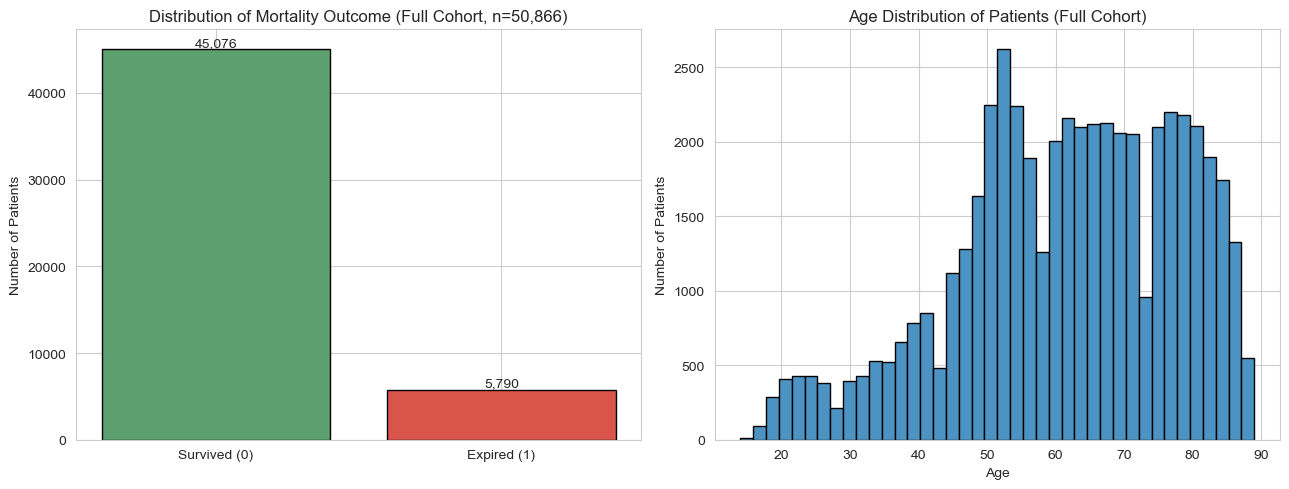

Graph save ho gaya: mortality_distribution.png
Total patients in this figure: 50,866  (matches thesis cohort size)


In [70]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graph 1: Mortality distribution (FULL cleaned cohort, train+test dono, newborn-exclusion ke baad)
mortality_counts = y.value_counts().sort_index()
labels = ['Survived (0)', 'Expired (1)']
axes[0].bar(labels, mortality_counts.values, color=['#5BA06E', '#D9554C'], edgecolor='black')
axes[0].set_title('Distribution of Mortality Outcome (Full Cohort, n=50,866)')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(mortality_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Graph 2: Age distribution (FULL cleaned cohort)
axes[1].hist(data['age'].dropna(), bins=40, color='#4C92C3', edgecolor='black')
axes[1].set_title('Age Distribution of Patients (Full Cohort)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.savefig('mortality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph save ho gaya: mortality_distribution.png")
print(f"Total patients in this figure: {len(y):,}  (matches thesis cohort size)")


In [71]:
import inspect
print(inspect.getsource(add_missing))

def add_missing(data, rate, mechanism='MCAR', random_state=42):
    rng = np.random.RandomState(random_state)
    df_miss = data.copy()
    num_cols = df_miss.select_dtypes(include=[np.number]).columns.tolist()

    mar_driver = 'age' if 'age' in df_miss.columns else num_cols[0]
    driver_median = df_miss[mar_driver].median()

    for col in num_cols:
        if mechanism == 'MCAR':
            mask = rng.rand(len(df_miss)) < rate
        elif mechanism == 'MAR':
            prob = np.where(df_miss[mar_driver] > driver_median, rate*1.5, rate*0.5)
            mask = rng.rand(len(df_miss)) < prob
        else:  # MNAR
            median = df_miss[col].median()
            prob = np.where(df_miss[col] > median, rate*1.5, rate*0.5)
            mask = rng.rand(len(df_miss)) < prob
        df_miss.loc[mask, col] = np.nan
    return df_miss



In [72]:
# Age ke masle check karें
print("=== AGE check ===")
print("Age range:", df['age'].min(), "se", df['age'].max())
print()
print("Age = 0 (newborns):", (df['age'] == 0).sum())
print("Age >= 300 (de-identified):", (df['age'] >= 300).sum())
print("Age 90-100 ke beech:", ((df['age'] >= 90) & (df['age'] < 300)).sum())
print()
print("Sabse zyada age values:")
print(df['age'].value_counts().sort_index(ascending=False).head(10))

=== AGE check ===
Age range: 0 se 89

Age = 0 (newborns): 8110
Age >= 300 (de-identified): 0
Age 90-100 ke beech: 0

Sabse zyada age values:
age
89       1
88     549
87     575
86     754
85     785
84     959
83     970
82     931
81    1046
80    1060
Name: count, dtype: int64


In [73]:
# Newborns vs Adults mein mortality compare
print("=== Newborns (age=0) vs Adults ===")
nb = df[df['age']==0]
ad = df[df['age']>0]

print(f"Newborns (age=0): {len(nb)} patients")
print(f"  Mortality rate: {nb['ExpiredHospital'].mean()*100:.1f}%")
print()
print(f"Adults (age>0): {len(ad)} patients")
print(f"  Mortality rate: {ad['ExpiredHospital'].mean()*100:.1f}%")
print()
print("Agar dono ki mortality bohot alag hai -> hatana zaroori (confound)")

=== Newborns (age=0) vs Adults ===
Newborns (age=0): 8110 patients
  Mortality rate: 0.8%

Adults (age>0): 50866 patients
  Mortality rate: 11.4%

Agar dono ki mortality bohot alag hai -> hatana zaroori (confound)


In [74]:
import json

notebook_path = "journal paper .ipynb"

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = json.load(f)

with open('all_code.txt', 'w', encoding='utf-8') as out:
    for i, cell in enumerate(nb['cells']):
        if cell['cell_type'] == 'code':
            out.write(f"\n# ===== CELL {i} =====\n")
            out.write(''.join(cell['source']))
            out.write('\n')

print("Done! 'all_code.txt' ban gayi hai — folder mein dekhein.")

Done! 'all_code.txt' ban gayi hai — folder mein dekhein.


In [75]:
from sklearn.metrics import roc_auc_score
overall_auroc = roc_auc_score(y_test_reset, y_pred_series)
print(f"Overall AUROC (leakage-fixed model): {overall_auroc:.3f}")

Overall AUROC (leakage-fixed model): 0.657


In [76]:
import numpy as np
print("Numeric columns in X_train:")
print(X_train.select_dtypes(include=[np.number]).columns.tolist())
print()
print("Total numeric columns:", len(X_train.select_dtypes(include=[np.number]).columns))
print()
print("Saare columns aur unka type:")
print(X_train.dtypes)

Numeric columns in X_train:
['age']

Total numeric columns: 1

Saare columns aur unka type:
gender            object
age                int64
admit_type        object
admit_location    object
AdmitDiagnosis    object
insurance         object
religion          object
marital_status    object
ethnicity         object
AdmitProcedure    object
dtype: object


gender: DP=0.054, EOD=0.051, FNR=0.017
insurance: DP=0.289, EOD=0.427, FNR=0.427
age_band: DP=0.449, EOD=0.515, FNR=0.515
ethnicity: DP=0.462, EOD=0.505, FNR=0.505

 Attribute  DP_point  DP_CI_low  DP_CI_high  EOD_point  EOD_CI_low  EOD_CI_high  FNR_point  FNR_CI_low  FNR_CI_high
   gender     0.054      0.035       0.072      0.051       0.034        0.075      0.017       0.001        0.071
insurance     0.289      0.249       0.330      0.427       0.239        0.683      0.427       0.210        0.683
 age_band     0.449      0.424       0.475      0.515       0.406        0.649      0.515       0.390        0.649
ethnicity     0.462      0.310       0.536      0.505       0.405        1.000      0.505       0.380        1.000


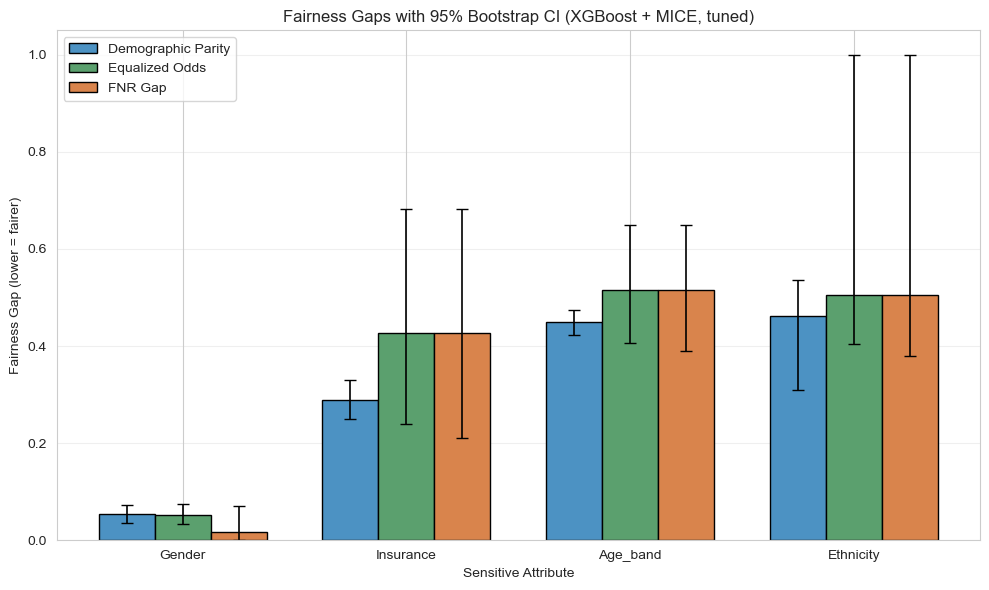

Fairness graph (tuned, Equalized Odds) save ho gaya: fairness_metrics.png


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== STEP 1: Bootstrap CI dobara calculate karo — CURRENT (tuned) xgb_best se =====
proba_current = xgb_best.predict_proba(X_te_best)[:, 1]
pred_current = (proba_current >= 0.5).astype(int)

y_true_arr = y_test.reset_index(drop=True).values
attributes = ['gender', 'insurance', 'age_band', 'ethnicity']

rng = np.random.RandomState(42)
n_boot = 1000
n_test = len(y_true_arr)

ci_rows = []
for attr in attributes:
    sens_arr = sens_test[attr].reset_index(drop=True).values

    # Point estimates (current tuned model se)
    _, point_gaps = fairness_metrics(y_test, pred_current, sens_test[attr])

    # Bootstrap: DP, Equalized Odds, FNR — teeno track karo
    boot_dp, boot_eod, boot_fnr = [], [], []
    for i in range(n_boot):
        idx = rng.choice(n_test, n_test, replace=True)
        _, bg = fairness_metrics(y_true_arr[idx], pred_current[idx], sens_arr[idx])
        if bg is not None:
            boot_dp.append(bg['Demographic_Parity_Diff'])
            boot_eod.append(bg['Equalized_Odds_Diff'])
            boot_fnr.append(bg['FNR_Gap'])

    dp_ci = np.percentile(boot_dp, [2.5, 97.5])
    eod_ci = np.percentile(boot_eod, [2.5, 97.5])
    fnr_ci = np.percentile(boot_fnr, [2.5, 97.5])

    ci_rows.append({
        'Attribute': attr,
        'DP_point': point_gaps['Demographic_Parity_Diff'], 'DP_CI_low': dp_ci[0], 'DP_CI_high': dp_ci[1],
        'EOD_point': point_gaps['Equalized_Odds_Diff'], 'EOD_CI_low': eod_ci[0], 'EOD_CI_high': eod_ci[1],
        'FNR_point': point_gaps['FNR_Gap'], 'FNR_CI_low': fnr_ci[0], 'FNR_CI_high': fnr_ci[1],
    })
    print(f"{attr}: DP={point_gaps['Demographic_Parity_Diff']:.3f}, EOD={point_gaps['Equalized_Odds_Diff']:.3f}, FNR={point_gaps['FNR_Gap']:.3f}")

fairness_ci_df = pd.DataFrame(ci_rows)
print("\n", fairness_ci_df.round(3).to_string(index=False))
fairness_ci_df.to_csv('fairness_metrics_with_CI.csv', index=False)

# ===== STEP 2: Graph banao — Equalized Odds ke sath (Equal Opportunity nahi) =====
point_cols = ['DP_point', 'EOD_point', 'FNR_point']
low_cols   = ['DP_CI_low', 'EOD_CI_low', 'FNR_CI_low']
high_cols  = ['DP_CI_high', 'EOD_CI_high', 'FNR_CI_high']
metric_labels = ['Demographic Parity', 'Equalized Odds', 'FNR Gap']
colors = ['#4C92C3', '#5BA06E', '#D9844C']

x = np.arange(len(attributes))
width = 0.25

plt.figure(figsize=(10, 6))
for i, (pc, lc, hc, label, c) in enumerate(zip(point_cols, low_cols, high_cols, metric_labels, colors)):
    points = fairness_ci_df[pc].values
    lower_err = np.clip(points - fairness_ci_df[lc].values, 0, None)
    upper_err = np.clip(fairness_ci_df[hc].values - points, 0, None)
    plt.bar(x + i*width, points, width, label=label, color=c, edgecolor='black',
             yerr=[lower_err, upper_err], capsize=4, error_kw={'elinewidth': 1.2, 'ecolor': 'black'})

plt.xlabel('Sensitive Attribute')
plt.ylabel('Fairness Gap (lower = fairer)')
plt.title('Fairness Gaps with 95% Bootstrap CI (XGBoost + MICE, tuned)')
plt.xticks(x + width, [a.capitalize() for a in attributes])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fairness_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fairness graph (tuned, Equalized Odds) save ho gaya: fairness_metrics.png")

In [78]:
print("="*60)
print("THESIS KE LIYE FINAL RESULTS — SAB EK JAGAH")
print("="*60)

print("\n### TABLE 4.1 — Best Model Performance ###")
print(f"AUROC:        {auroc:.3f}  (95% CI: {ci_low_overall:.3f}-{ci_high_overall:.3f})")
print(f"AUPRC:        {auprc:.3f}")
print(f"Sensitivity:  {sensitivity:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision:.3f}")
print(f"F1-score:     {f1:.3f}")
print(f"Brier Score:  {brier:.3f}")
print(f"Cross-Val AUROC: {all_scores.mean():.3f} +/- {all_scores.std():.3f} ({len(all_scores)} folds)")

print("\n### TABLE 4.2 — Imputation x Model Comparison ###")
print(pd.read_csv('imputation_model_results.csv').to_string(index=False))

print("\n### TABLE 4.3 — Fairness Metrics with Bootstrap CI ###")
print(fairness_ci_df.to_string(index=False))

print("\n### TABLE 4.4 — SHAP Top 10 Features ###")
print(pd.read_csv('shap_stability.csv', index_col=0).head(10).round(3).to_string())

print("\n### TABLE 4.5 — RQ1: Missingness Mechanism x Rate (AUROC/AUPRC) ###")
print(exp_df.to_string(index=False))

print("\n### STATISTICAL TESTS ###")
print(f"MICE vs Native AUROC diff, 95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"McNemar p-value: {result.pvalue:.4f}")
print(f"Wilcoxon (tuned vs orig) p-value: {p_value:.4f}")

print("\n### HYPERPARAMETER TUNING ###")
print("Best params:", search.best_params_)
print(f"Best CV AUROC: {search.best_score_:.3f}")

print("\n### DATA CHARACTERISTICS ###")
print(f"Total patients (after newborn removal): {data.shape[0]}")
print(f"Mortality rate: {y.mean()*100:.1f}%")
print(f"Age range: {data['age'].min()} to {data['age'].max()} (no 300-artifact found)")
print(f"Admission-time features used: {X.shape[1]}")

THESIS KE LIYE FINAL RESULTS — SAB EK JAGAH

### TABLE 4.1 — Best Model Performance ###
AUROC:        0.786  (95% CI: 0.773-0.799)
AUPRC:        0.339
Sensitivity:  0.500
Specificity:  0.729
Precision:    0.249
F1-score:     0.368
Brier Score:  0.182
Cross-Val AUROC: 0.781 +/- 0.006 (15 folds)

### TABLE 4.2 — Imputation x Model Comparison ###
Imputation              Model  AUROC  AUPRC
      Mean LogisticRegression  0.643  0.170
      Mean       RandomForest  0.736  0.278
      Mean            XGBoost  0.777  0.343
    Median LogisticRegression  0.643  0.170
    Median       RandomForest  0.738  0.276
    Median            XGBoost  0.772  0.338
       KNN LogisticRegression  0.642  0.170
       KNN       RandomForest  0.737  0.277
       KNN            XGBoost  0.771  0.331
      MICE LogisticRegression  0.643  0.170
      MICE       RandomForest  0.738  0.284
      MICE            XGBoost  0.769  0.332
MissForest LogisticRegression  0.643  0.170
MissForest       RandomForest  0.738  